In [1]:
# ============================================================
# 0) Setup (Python 3.12 compatible)
# ============================================================
# - pytorch-forecasting >= 1.3 works with Py3.12 and Lightning >= 2.2
# - LightGBM for tabular
# ============================================================

!pip -q install "pytorch-forecasting>=1.3,<1.5" "lightning>=2.2,<2.5" lightgbm

import warnings, os, sys, math, time, numpy as np, pandas as pd
warnings.filterwarnings("ignore")

print("Python :", sys.version)
import torch, lightning
import pytorch_forecasting as pf
import lightgbm as lgb
from lightning.pytorch import Trainer, seed_everything
from sklearn.metrics import mean_squared_error, mean_absolute_error
print("Torch  :", torch.__version__)
print("Ltning :", lightning.__version__)
print("PF     :", pf.__version__)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.9/260.9 kB 13.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 811.0/811.0 kB 19.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.5/65.5 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.2/983.2 kB 52.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.2/829.2 kB 26.4 MB/s eta 0:00:00
Python : 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
Torch  : 2.8.0+cu126
Ltning : 2.4.0
PF     : 1.4.0


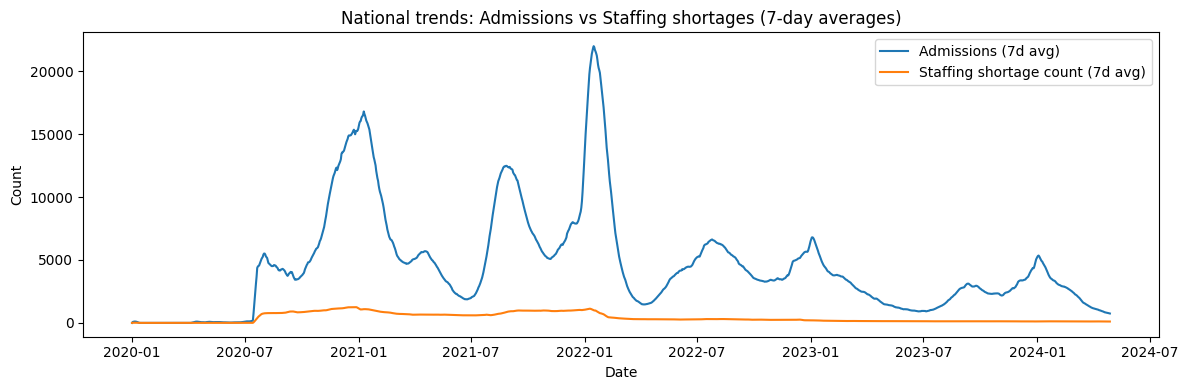

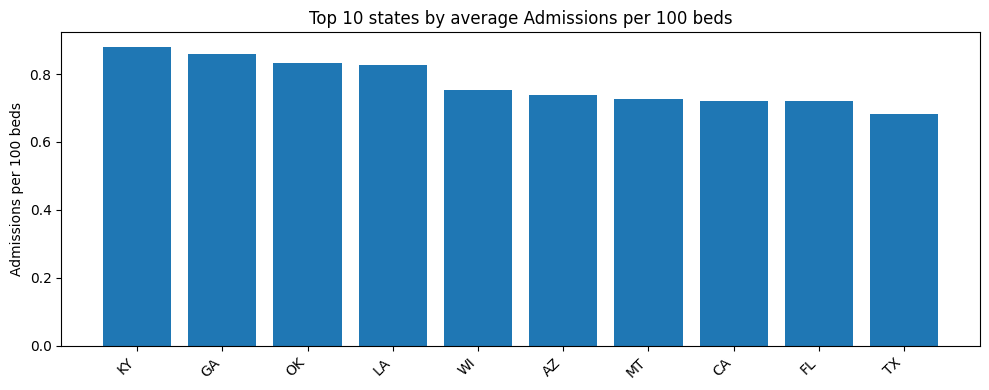

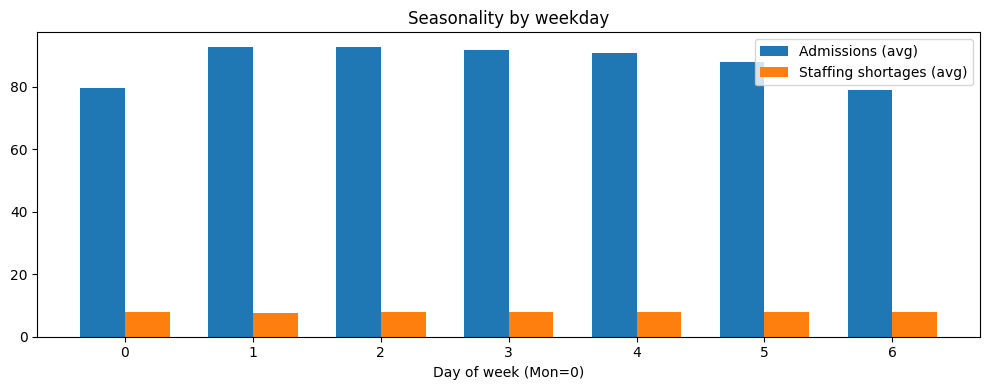

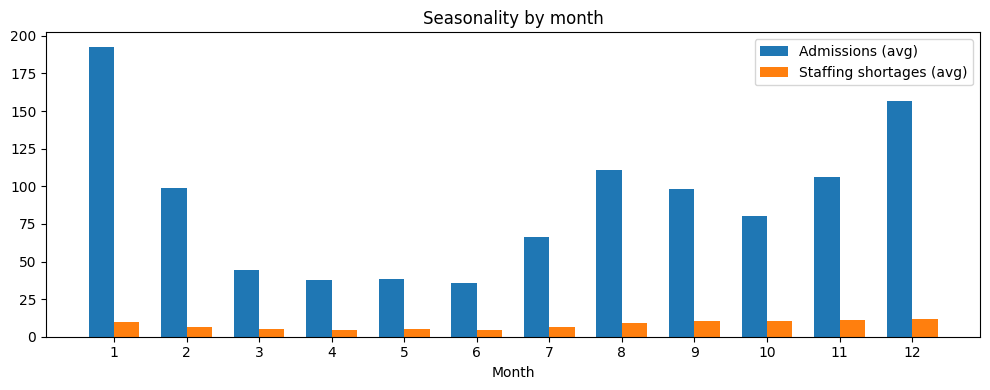

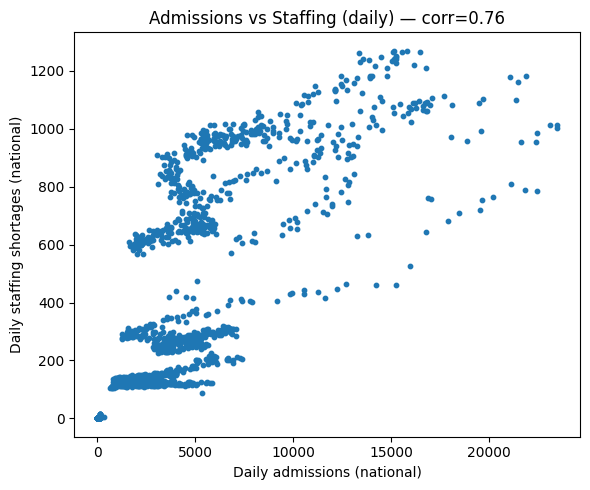

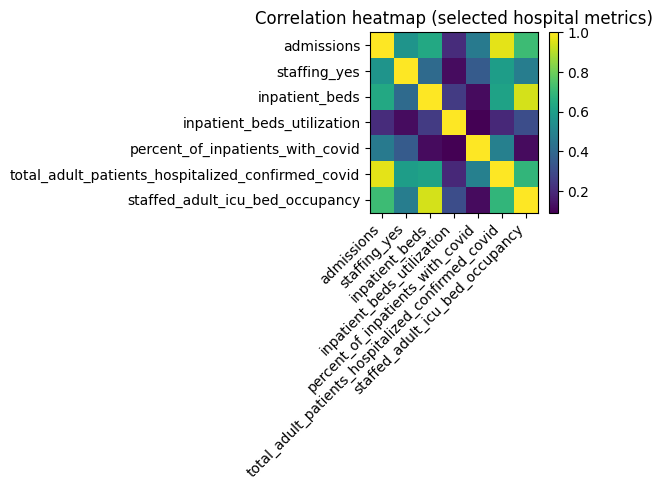

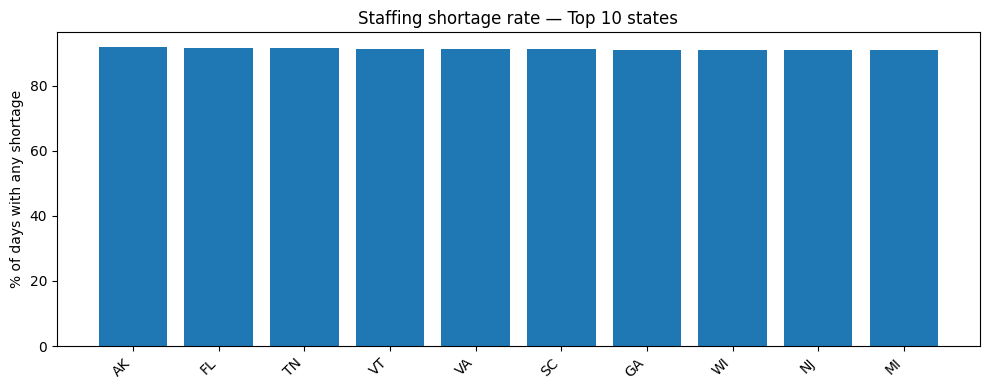

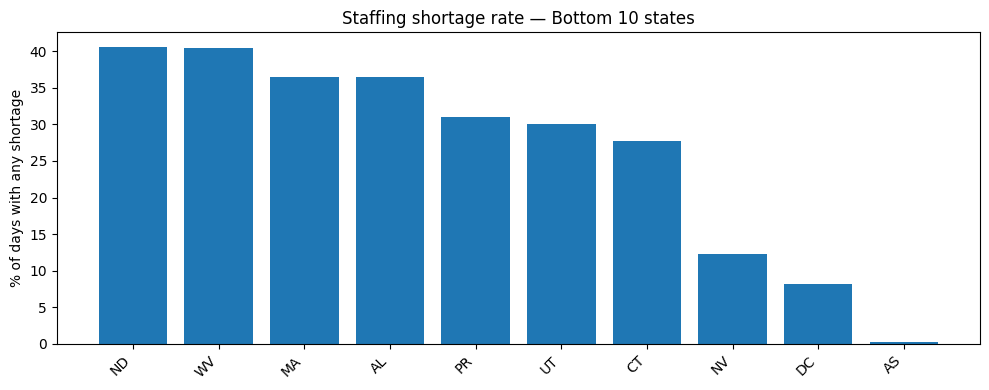

In [2]:
# =========================
# COVID Hospital EDA (Admissions & Staffing)
# =========================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ---------- 1) Load ----------
url = "https://healthdata.gov/api/views/g62h-syeh/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(url)

# unify date column
date_col = "date" if "date" in df.columns else ("collection_date" if "collection_date" in df.columns else None)
if date_col is None:
    raise ValueError("No date column found (expected 'date' or 'collection_date').")
df[date_col] = pd.to_datetime(df[date_col])
df = df.sort_values([date_col, "state"]).reset_index(drop=True)

# keep only columns we use (if missing, fill with 0)
def exists(c): return c in df.columns

# admissions = adult confirmed + pediatric confirmed (confirmed-only baseline)
ad_adm = "previous_day_admission_adult_covid_confirmed"
pd_adm = "previous_day_admission_pediatric_covid_confirmed"
df["admissions"] = df.get(ad_adm, 0).fillna(0) + df.get(pd_adm, 0).fillna(0)

# staffing_yes = number of facilities reporting a staffing shortage today
staff_yes_col = "critical_staffing_shortage_today_yes"
if not exists(staff_yes_col):
    raise ValueError("Expected 'critical_staffing_shortage_today_yes' not found.")
df["staffing_yes"] = df[staff_yes_col].fillna(0)

# optional helpful covariates (fill if missing)
for c in [
    "inpatient_beds", "inpatient_beds_utilization",
    "percent_of_inpatients_with_covid",
    "total_adult_patients_hospitalized_confirmed_covid",
    "staffed_adult_icu_bed_occupancy"
]:
    if not exists(c):
        df[c] = 0.0
    df[c] = pd.to_numeric(df[c], errors="coerce").fillna(0.0)

# date parts
df["dayofweek"] = df[date_col].dt.dayofweek
df["month"] = df[date_col].dt.month
df["year"] = df[date_col].dt.year

# ensure state is string/categorical
df["state"] = df["state"].astype(str)

# ---------- 2) National daily aggregates ----------
nat = (df.groupby(df[date_col])
         .agg(admissions=("admissions","sum"),
              staffing_yes=("staffing_yes","sum"),
              inpatient_beds=("inpatient_beds","sum"))
         .reset_index()
         .sort_values(date_col))
# 7-day averages
nat["adm_7d"] = nat["admissions"].rolling(7, min_periods=1).mean()
nat["staff_7d"] = nat["staffing_yes"].rolling(7, min_periods=1).mean()

# ---------- 3) State-level summaries ----------
state_daily = (df.groupby(["state", df[date_col]])
                 .agg(admissions=("admissions","sum"),
                      staffing_yes=("staffing_yes","sum"),
                      inpatient_beds=("inpatient_beds","sum"))
                 .reset_index()
                 .sort_values([ "state", date_col ]))

# admissions per 100 beds (avoid div by 0)
tmp = state_daily.copy()
tmp["adm_per_100_beds"] = np.where(tmp["inpatient_beds"]>0, 100.0 * tmp["admissions"] / tmp["inpatient_beds"], np.nan)
top_states = (tmp.groupby("state")["adm_per_100_beds"]
                .mean().dropna().sort_values(ascending=False).head(10))

# staffing shortage rate (share of days with any shortage)
state_daily["staffing_bin"] = (state_daily["staffing_yes"] > 0).astype(int)
staff_rate = (state_daily.groupby("state")["staffing_bin"]
                .mean().sort_values(ascending=False))  # 0..1

# ---------- 4) Seasonality (weekday / month) ----------
wk = (df.groupby("dayofweek")
        .agg(admissions=("admissions","mean"),
             staffing_yes=("staffing_yes","mean"))
        .reset_index())

mo = (df.groupby("month")
        .agg(admissions=("admissions","mean"),
             staffing_yes=("staffing_yes","mean"))
        .reset_index())

# ---------- 5) Correlation heatmap ----------
corr_cols = ["admissions","staffing_yes","inpatient_beds",
             "inpatient_beds_utilization","percent_of_inpatients_with_covid",
             "total_adult_patients_hospitalized_confirmed_covid",
             "staffed_adult_icu_bed_occupancy"]
corr_df = df[corr_cols].copy()
corr = corr_df.corr(numeric_only=True).values
corr_labels = corr_df.columns.tolist()

# ---------- 6) Scatter: admissions vs staffing (national daily) ----------
x_sc = nat["admissions"].values
y_sc = nat["staffing_yes"].values
corr_xy = np.corrcoef(x_sc, y_sc)[0,1] if len(x_sc) > 1 else np.nan

# =========================
# PLOTS
# =========================

# A) National trend: admissions vs staffing (7d avg)
plt.figure(figsize=(12,4))
plt.plot(nat[date_col], nat["adm_7d"], label="Admissions (7d avg)")
plt.plot(nat[date_col], nat["staff_7d"], label="Staffing shortage count (7d avg)")
plt.title("National trends: Admissions vs Staffing shortages (7-day averages)")
plt.xlabel("Date"); plt.ylabel("Count"); plt.legend(); plt.tight_layout(); plt.show()

# B) Top 10 states: admissions per 100 beds (bar)
plt.figure(figsize=(10,4))
x = np.arange(len(top_states.index))
plt.bar(x, top_states.values)
plt.xticks(x, top_states.index, rotation=45, ha="right")
plt.title("Top 10 states by average Admissions per 100 beds")
plt.ylabel("Admissions per 100 beds"); plt.tight_layout(); plt.show()

# C) Seasonality by weekday (Mon=0..Sun=6)
plt.figure(figsize=(10,4))
x = np.arange(len(wk))
w = 0.35
plt.bar(x - w/2, wk["admissions"].values, width=w, label="Admissions (avg)")
plt.bar(x + w/2, wk["staffing_yes"].values, width=w, label="Staffing shortages (avg)")
plt.xticks(x, wk["dayofweek"].astype(int))
plt.xlabel("Day of week (Mon=0)"); plt.title("Seasonality by weekday")
plt.legend(); plt.tight_layout(); plt.show()

# D) Seasonality by month
plt.figure(figsize=(10,4))
x = np.arange(len(mo))
w = 0.35
plt.bar(x - w/2, mo["admissions"].values, width=w, label="Admissions (avg)")
plt.bar(x + w/2, mo["staffing_yes"].values, width=w, label="Staffing shortages (avg)")
plt.xticks(x, mo["month"].astype(int))
plt.xlabel("Month"); plt.title("Seasonality by month")
plt.legend(); plt.tight_layout(); plt.show()

# E) Scatter: admissions vs staffing (national daily)
plt.figure(figsize=(6,5))
plt.scatter(x_sc, y_sc, s=10)
plt.xlabel("Daily admissions (national)"); plt.ylabel("Daily staffing shortages (national)")
plt.title(f"Admissions vs Staffing (daily) — corr={corr_xy:.2f}")
plt.tight_layout(); plt.show()

# F) Correlation heatmap (selected metrics)
plt.figure(figsize=(6,5))
plt.imshow(corr, interpolation="nearest", aspect="auto")
plt.xticks(np.arange(len(corr_labels)), corr_labels, rotation=45, ha="right")
plt.yticks(np.arange(len(corr_labels)), corr_labels)
plt.colorbar()
plt.title("Correlation heatmap (selected hospital metrics)")
plt.tight_layout(); plt.show()

# G) Staffing shortage rate by state (top & bottom 10)
sr = staff_rate
top10 = sr.head(10); bot10 = sr.tail(10)

plt.figure(figsize=(10,4))
x = np.arange(len(top10))
plt.bar(x, 100*top10.values)
plt.xticks(x, top10.index, rotation=45, ha="right")
plt.ylabel("% of days with any shortage")
plt.title("Staffing shortage rate — Top 10 states")
plt.tight_layout(); plt.show()

plt.figure(figsize=(10,4))
x = np.arange(len(bot10))
plt.bar(x, 100*bot10.values)
plt.xticks(x, bot10.index, rotation=45, ha="right")
plt.ylabel("% of days with any shortage")
plt.title("Staffing shortage rate — Bottom 10 states")
plt.tight_layout(); plt.show()


In [3]:
# ============================================================
# 1) Load & Preprocess HealthData.gov HHS Hospital dataset
# ============================================================
import pandas as pd
import numpy as np

seed_everything(42, workers=True)

URL = "https://healthdata.gov/api/views/g62h-syeh/rows.csv?accessType=DOWNLOAD"
df = pd.read_csv(URL)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


In [4]:

# Make sure date column exists and standardize name
if "date" in df.columns:
    df["collection_date"] = pd.to_datetime(df["date"])
else:
    raise ValueError("Expected 'date' column not found. Inspect df.columns.")

# --- Targets ---
# Admissions (adult + pediatric confirmed)
for col in [
    "previous_day_admission_adult_covid_confirmed",
    "previous_day_admission_pediatric_covid_confirmed",
    "inpatient_beds",
    "total_adult_patients_hospitalized_confirmed_covid",
    "percent_of_inpatients_with_covid",
    "inpatient_beds_utilization",
    "inpatient_beds_utilization_numerator",
    "inpatient_beds_utilization_denominator",
]:
    if col not in df.columns:
        df[col] = 0

df["admissions"] = (
    df["previous_day_admission_adult_covid_confirmed"].fillna(0) +
    df["previous_day_admission_pediatric_covid_confirmed"].fillna(0)
).astype(float)

# Staffing shortage: number of hospitals reporting "yes" (we'll model as a count)
df["staffing_yes"] = df["critical_staffing_shortage_today_yes"].fillna(0).astype(float)

# --- Aggregate to state-day (more stable than facility-level) ---
state_daily = (
    df.groupby(["collection_date", "state"], as_index=False)
      .agg({
          "admissions":"sum",
          "staffing_yes":"sum",
          "inpatient_beds":"sum",
          "total_adult_patients_hospitalized_confirmed_covid":"sum",
          "percent_of_inpatients_with_covid":"mean",
          "inpatient_beds_utilization":"mean",
      })
      .sort_values(["state","collection_date"])
      .reset_index(drop=True)
)

# --- Basic time features ---
state_daily["dayofweek"] = state_daily["collection_date"].dt.dayofweek
state_daily["month"] = state_daily["collection_date"].dt.month
state_daily["state"] = state_daily["state"].astype("category")

# --- time_idx per state ---
state_daily["time_idx"] = state_daily.groupby("state").cumcount()

# Optional smoothing helper columns (not used by TFT, but we might use in hybrid)
for t in ["admissions", "staffing_yes"]:
    state_daily[f"{t}_roll7"] = (
        state_daily.groupby("state")[t].transform(lambda s: s.rolling(7, min_periods=1).mean())
    )

# Binary staffing flag for classification
state_daily["staffing_bin"] = (state_daily["staffing_yes"] > 0).astype(int)


print(state_daily.head())
print("States:", state_daily["state"].nunique(), "Rows:", len(state_daily))



  collection_date state  admissions  staffing_yes  inpatient_beds  \
0      2020-03-23    AK         0.0           0.0            56.0   
1      2020-03-24    AK         0.0           0.0            56.0   
2      2020-03-25    AK         0.0           0.0            56.0   
3      2020-03-26    AK         0.0           0.0            56.0   
4      2020-03-27    AK         0.0           0.0            81.0   

   total_adult_patients_hospitalized_confirmed_covid  \
0                                                0.0   
1                                                0.0   
2                                                0.0   
3                                                0.0   
4                                                0.0   

   percent_of_inpatients_with_covid  inpatient_beds_utilization  dayofweek  \
0                          0.142857                    0.375000          0   
1                          0.150000                    0.357143          1   
2             

In [5]:
# ============================================================
# 2) Utilities: metrics, windows, robust TFT prediction handler
# ============================================================
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error

def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

def mae(y_true, y_pred):
    return float(mean_absolute_error(y_true, y_pred))

# Build supervised windows for the hybrid model
def make_windows_with_meta(df_state, target_col, lookback=30, horizon=1):
    X_seq, X_meta, y = [], [], []
    vals = df_state[target_col].values.astype(float)
    for i in range(len(df_state) - lookback - horizon + 1):
        w = vals[i:i+lookback]
        t = i + lookback  # predict next step

        # meta features: window stats, lags, calendar + exogenous
        lag1  = (w[-1] - w[-2]) if lookback >= 2 else 0.0
        lag7  = (w[-1] - w[-7]) if lookback >= 7 else 0.0
        lag14 = (w[-1] - w[-14]) if lookback >= 14 else 0.0

        meta = [
            w[-1], w.mean(), (w.std() if np.isfinite(w.std()) else 0.0), w.min(), w.max(),
            lag1, lag7, lag14,
            df_state.loc[t, "dayofweek"], df_state.loc[t, "month"],
            df_state.loc[t, "inpatient_beds"],
            df_state.loc[t, "total_adult_patients_hospitalized_confirmed_covid"],
            df_state.loc[t, "percent_of_inpatients_with_covid"],
            df_state.loc[t, "inpatient_beds_utilization"],
            df_state.loc[t, f"{target_col}_roll7"],
        ]
        X_seq.append(w)
        X_meta.append(meta)
        y.append(vals[t])
    return np.array(X_seq), np.array(X_meta), np.array(y)

# Robust TFT prediction getter (handles version differences/quantiles)
import torch
def tft_predict_and_targets(model, loader):
    try:
        out = model.predict(loader, return_y=True, return_index=True)
        if isinstance(out, tuple):
            preds = out[0]
            y = out[-1]
        else:
            preds = out
            raw, x = model.predict(loader, mode="raw", return_x=True)
            preds = raw["prediction"] if isinstance(raw, dict) and "prediction" in raw else raw
            y = x["decoder_target"]
    except Exception:
        raw, x = model.predict(loader, mode="raw", return_x=True)
        preds = raw["prediction"] if isinstance(raw, dict) and "prediction" in raw else raw
        y = x["decoder_target"]

    if isinstance(preds, torch.Tensor):
        preds = preds.detach().cpu().numpy()
    if isinstance(y, torch.Tensor):
        y = y.detach().cpu().numpy()

    # If quantiles present: [N, horizon, Q] -> pick median quantile
    if preds.ndim == 3:
        q_mid = preds.shape[-1] // 2
        preds = preds[..., q_mid]

    # Flatten horizon
    return preds.reshape(-1), y.reshape(-1)


In [6]:
# ==== METRIC HELPERS ====
import numpy as np
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, precision_score, recall_score, f1_score
)

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float).reshape(-1)
    y_pred = np.asarray(y_pred).astype(float).reshape(-1)
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))

    # MAPE (ignore true==0 to avoid div/0)
    with np.errstate(divide='ignore', invalid='ignore'):
        ape = np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))
    mape = float(np.nanmean(ape) * 100.0)

    r2 = r2_score(y_true, y_pred)
    return {"MAE": mae, "RMSE": rmse, "MAPE%": mape, "R2": float(r2)}

def classification_metrics(y_true, y_score, threshold=0.5):
    y_true = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)
    n = min(len(y_true), len(y_score))
    y_true, y_score = y_true[:n], y_score[:n]

    # AUROC on scores; handle single-class edge case
    auroc = float("nan")
    if len(np.unique(y_true)) > 1:
        auroc = float(roc_auc_score(y_true, y_score))

    y_pred = (y_score >= threshold).astype(int)
    precision = float(precision_score(y_true, y_pred, zero_division=0))
    recall    = float(recall_score(y_true, y_pred, zero_division=0))
    f1        = float(f1_score(y_true, y_pred, zero_division=0))
    return {"AUROC": auroc, "Precision": precision, "Recall": recall, "F1": f1}

def classification_metrics_from_probs(y_true, p1, thr=0.5):
    y_true = np.asarray(y_true, int).reshape(-1)
    p1 = np.clip(np.asarray(p1, float).reshape(-1), 1e-9, 1-1e-9)
    n = min(len(y_true), len(p1))
    y_true, p1 = y_true[:n], p1[:n]
    auroc = float("nan") if len(np.unique(y_true))<2 else float(roc_auc_score(y_true, p1))
    y_pred = (p1 >= thr).astype(int)
    prec = float(precision_score(y_true, y_pred, zero_division=0))
    rec  = float(recall_score(y_true, y_pred, zero_division=0))
    f1   = float(f1_score(y_true, y_pred, zero_division=0))
    return {"AUROC": auroc, "Precision": prec, "Recall": rec, "F1": f1}


In [7]:
import numpy as np, torch

def _to_numpy_any(x):
    """Convert nested (tuple/list/dict/tensor/ndarray) to a flat numpy array if possible."""
    if x is None:
        return None

    # If it's already a tensor/array, return it
    if isinstance(x, torch.Tensor):
        return x.detach().cpu().numpy()
    if isinstance(x, np.ndarray):
        return x

    # If it's a dict, prefer decoder_target/prediction keys
    if isinstance(x, dict):
        for key in ("decoder_target", "target", "y", "prediction", "preds"):
            if key in x:
                return _to_numpy_any(x[key])
        # otherwise, try any ndarray/tensor field
        for v in x.values():
            arr = _to_numpy_any(v)
            if arr is not None:
                return arr
        return None

    # If it's a tuple/list, flatten convertible parts
    if isinstance(x, (list, tuple)):
        parts = []
        for v in x:
            arr = _to_numpy_any(v)
            if arr is not None:
                parts.append(arr.reshape(-1))
        if parts:
            try:
                return np.concatenate(parts, axis=0)
            except Exception:
                return parts[-1]  # best effort
        return None

    return None  # unsupported type

# --- Robust TFT predictor & target collector (version-proof) ---
import numpy as np, torch
# --- robust TFT predictor that works across PF/Lightning versions ---
import numpy as np, torch

def tft_predict_and_targets(model, loader, keep_horizon=False):
    """
    Returns:
      preds_flat, y_flat
      and if keep_horizon=True: (preds_h, y_h) where shape is [N, horizon]
    """
    # 1) predictions
    try:
        preds = model.predict(loader)  # may be tensor/tuple/dict
    except Exception:
        preds = None
    if preds is None:
        raw = model.predict(loader, mode="raw")
        if isinstance(raw, dict) and "prediction" in raw:
            preds = raw["prediction"]
        elif isinstance(raw, (list, tuple)) and raw:
            preds = raw[0]
        else:
            preds = raw

    if isinstance(preds, (list, tuple)) and len(preds) == 1:
        preds = preds[0]
    if isinstance(preds, dict) and "prediction" in preds:
        preds = preds["prediction"]
    if isinstance(preds, torch.Tensor):
        preds = preds.detach().cpu().numpy()
    preds = np.asarray(preds)

    # If quantiles present: [N, horizon, Q] -> take median quantile
    if preds.ndim == 3:
        preds = preds[..., preds.shape[-1] // 2]

    preds_h = preds if preds.ndim == 2 else preds.reshape(-1, 1)
    preds_flat = preds_h.reshape(-1)

    # 2) collect y from loader (handles tuples like (y, weight))
    ys = []
    for batch in loader:
        if isinstance(batch, (list, tuple)) and len(batch) >= 2:
            yb = batch[1]
        else:
            xb = batch[0] if isinstance(batch, (list, tuple)) else batch
            if isinstance(xb, dict) and "decoder_target" in xb:
                yb = xb["decoder_target"]
            else:
                continue
        if isinstance(yb, (list, tuple)) and len(yb) >= 1:
            yb = yb[0]
        if isinstance(yb, torch.Tensor):
            yb = yb.detach().cpu().numpy()
        ys.append(np.asarray(yb))
    y = np.concatenate(ys, axis=0) if ys else np.array([])
    y_h = y if y.ndim == 2 else y.reshape(-1, 1)
    y_flat = y_h.reshape(-1)

    # align lengths
    n = min(len(preds_flat), len(y_flat))
    preds_flat, y_flat = preds_flat[:n], y_flat[:n]

    if keep_horizon:
        H = preds_h.shape[1]
        preds_h = preds_flat.reshape(-1, H)[: n // H]
        y_h = y_flat.reshape(-1, H)[: n // H]
        return preds_flat, y_flat, preds_h, y_h

    return preds_flat, y_flat


In [8]:
# --- FIX: use PF LightningMetric losses (RMSE/MAE) and output_size=1 ---
from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
from pytorch_forecasting.metrics import RMSE as RMSELoss, MAE as MAELoss
import torch
from lightning.pytorch import Trainer

def run_tft_predict(
    state_daily,
    target_col,
    task="reg",                      # "reg" for admissions, "clf" for staffing_bin (0/1)
    max_encoder_length=30,
    max_prediction_length=7,
    epochs=10,
    batch_size=64,
    keep_horizon=False,
    return_model=False,
):
    min_required = max_encoder_length + max_prediction_length

    # keep states long enough
    counts = state_daily.groupby("state")["time_idx"].count()
    valid_states = counts[counts >= min_required].index
    df_f = state_daily[state_daily["state"].isin(valid_states)].copy()

    # val = last (encoder+prediction) rows per state
    def tail_ctx(g): return g.iloc[-min_required:]
    val_df = (df_f.sort_values(["state","time_idx"])
                .groupby("state", group_keys=False)
                .apply(tail_ctx).reset_index(drop=True))
    val_keys = val_df[["state","time_idx"]].assign(_is_val=1)
    train_df = (df_f.merge(val_keys, on=["state","time_idx"], how="left")
                   .loc[lambda x: x["_is_val"].isna()]
                   .drop(columns="_is_val").reset_index(drop=True))

    # dataset (treat both targets as real-valued)
    train_ds = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target=target_col,
        group_ids=["state"],
        max_encoder_length=max_encoder_length,
        max_prediction_length=max_prediction_length,
        static_categoricals=["state"],
        time_varying_known_reals=["dayofweek","month"],
        time_varying_unknown_reals=[target_col],
        allow_missing_timesteps=True,
    )
    val_ds = TimeSeriesDataSet.from_dataset(train_ds, val_df, predict=True, stop_randomization=True)

    train_loader = train_ds.to_dataloader(train=True, batch_size=batch_size, num_workers=0)
    val_loader   = val_ds.to_dataloader(train=False, batch_size=batch_size, num_workers=0)

    # 🔧 Use a PF LightningMetric loss (works for both tasks)
    loss_fn = RMSELoss()  # or MAELoss() if you prefer
    tft = TemporalFusionTransformer.from_dataset(
        train_ds,
        learning_rate=1e-3,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.1,
        loss=loss_fn,
        optimizer="Adam",
        output_size=1,              # 1 value per time step
    )

    accelerator = "gpu" if torch.cuda.is_available() else "cpu"
    trainer = Trainer(max_epochs=epochs, accelerator=accelerator, devices=1,
                      gradient_clip_val=0.1, log_every_n_steps=50)
    trainer.fit(tft, train_loader, val_loader)

    # --- predictions/targets using your robust collector ---
    if keep_horizon:
        preds, y, preds_h, y_h = tft_predict_and_targets(tft, val_loader, keep_horizon=True)
    else:
        preds, y = tft_predict_and_targets(tft, val_loader, keep_horizon=False)

    out = {}
    if task == "clf":
        # train as regression, evaluate as classification
        logits = preds
        probs = 1.0 / (1.0 + np.exp(-logits))
        out.update({"logits": logits, "probs": probs, "y_true": y})
        if keep_horizon:
            out.update({"logits_h": preds_h, "y_true_h": y_h,
                        "probs_h": 1.0 / (1.0 + np.exp(-preds_h))})
    else:
        out.update({"y_pred": preds, "y_true": y})
        if keep_horizon:
            out.update({"y_pred_h": preds_h, "y_true_h": y_h})

    if return_model:
        out.update({"model": tft, "val_loader": val_loader})

    return out


In [9]:
from tensorflow import keras
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from lightgbm import LGBMRegressor, LGBMClassifier
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

def run_hybrid(state_daily, target_col, task="reg", states_to_eval=None, lookback=30, epochs=15, use_log1p=False):
    """
    task = "reg"  -> admissions (returns RMSE, MAE, MAPE%, R2)  [macro avg across states]
           "clf"  -> staffing_bin (returns AUROC, Precision, Recall, F1)  [macro avg across states]
    Also returns a 'detail' dict with counts and (for regression) global/micro metrics.
    """
    # pick states (default: longest 20) and ensure enough length
    counts = state_daily.groupby("state")["time_idx"].count()
    valid_states = counts[counts >= (lookback + 1)].index
    df_f = state_daily[state_daily["state"].isin(valid_states)].copy()

    if states_to_eval is None:
        states_to_eval = counts[valid_states].sort_values(ascending=False).head(20).index.tolist()

    # collectors
    reg_rmse, reg_mae, reg_mape, reg_r2 = [], [], [], []
    all_y_true, all_y_pred = [], []   # for global/micro metrics

    cls_auroc, cls_prec, cls_rec, cls_f1 = [], [], [], []

    # small helper
    def _reg_metrics(y_true, y_pred):
        y_true = np.asarray(y_true, float).reshape(-1)
        y_pred = np.asarray(y_pred, float).reshape(-1)
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        mae  = float(mean_absolute_error(y_true, y_pred))
        with np.errstate(divide='ignore', invalid='ignore'):
            ape = np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))
        mape = float(np.nanmean(ape) * 100.0)
        r2   = float(r2_score(y_true, y_pred))
        return rmse, mae, mape, r2

    for st in states_to_eval:
        df_state = df_f[df_f["state"] == st].copy().reset_index(drop=True)

        # ensure exogenous columns exist
        for col in ["inpatient_beds",
                    "total_adult_patients_hospitalized_confirmed_covid",
                    "percent_of_inpatients_with_covid",
                    "inpatient_beds_utilization",
                    f"{target_col}_roll7"]:
            if col not in df_state.columns:
                df_state[col] = 0.0

        # ---- windowing (reuses your earlier helper) ----
        X_seq, X_meta, y = make_windows_with_meta(df_state, target_col, lookback=lookback, horizon=1)
        if len(y) < 50:
            continue

        split = int(0.8 * len(X_seq))
        X_seq_tr, X_seq_te = X_seq[:split], X_seq[split:]
        X_meta_tr, X_meta_te = X_meta[:split], X_meta[split:]
        y_tr, y_te = y[:split], y[split:]

        # shapes/dtypes
        X_seq_tr = X_seq_tr.astype("float32")[..., None]
        X_seq_te = X_seq_te.astype("float32")[..., None]

        # ----- LSTM encoder with named embedding layer -----
        emb_dim = 32
        inp = Input(shape=(lookback, 1), name="seq")
        x = LSTM(64, name="lstm")(inp)
        x = Dropout(0.2, name="drop")(x)
        emb = Dense(emb_dim, activation="relu", name="emb")(x)

        if task == "clf":
            out = Dense(1, activation="sigmoid", name="out")(emb)
            lstm = Model(inp, out)
            lstm.compile(optimizer="adam", loss="binary_crossentropy")
            y_tr_trf = y_tr.astype("float32")
            y_te_trf = y_te.astype("float32")
        else:
            out = Dense(1, name="out")(emb)
            lstm = Model(inp, out)
            lstm.compile(optimizer="adam", loss="mse")
            y_tr_trf = (np.log1p(y_tr) if use_log1p else y_tr).astype("float32")
            y_te_trf = (np.log1p(y_te) if use_log1p else y_te).astype("float32")

        lstm.fit(X_seq_tr, y_tr_trf, epochs=epochs, batch_size=64, validation_split=0.2, verbose=0)

        # get embeddings
        emb_model = Model(lstm.input, lstm.get_layer("emb").output)
        emb_tr = emb_model.predict(X_seq_tr, verbose=0)
        emb_te = emb_model.predict(X_seq_te, verbose=0)

        # features = embedding + meta
        X_meta_tr = np.nan_to_num(X_meta_tr.astype("float32"))
        X_meta_te = np.nan_to_num(X_meta_te.astype("float32"))
        X_tr = np.hstack([emb_tr, X_meta_tr])
        X_te = np.hstack([emb_te, X_meta_te])

        if task == "clf":
            est = LGBMClassifier(
                objective="binary",
                learning_rate=0.05,
                num_leaves=63,
                max_depth=-1,
                min_child_samples=20,
                subsample=0.8,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                n_estimators=4000
            )
            est.fit(X_tr, y_tr.astype(int))
            y_score = est.predict_proba(X_te)[:, 1]
            y_pred  = (y_score >= 0.5).astype(int)

            # metrics
            # guard AUROC for single-class validation
            if len(np.unique(y_te)) > 1:
                from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
                cls_auroc.append(float(roc_auc_score(y_te.astype(int), y_score)))
            else:
                cls_auroc.append(float("nan"))
            from sklearn.metrics import precision_score, recall_score, f1_score
            cls_prec.append(float(precision_score(y_te.astype(int), y_pred, zero_division=0)))
            cls_rec.append(float(recall_score(y_te.astype(int), y_pred, zero_division=0)))
            cls_f1.append(float(f1_score(y_te.astype(int), y_pred, zero_division=0)))

        else:
            est = LGBMRegressor(
                objective=("poisson" if not use_log1p else "regression"),
                learning_rate=0.05,
                num_leaves=63,
                max_depth=-1,
                min_child_samples=20,
                subsample=0.8,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                n_estimators=4000
            )
            est.fit(X_tr, y_tr_trf)
            pred_trf = est.predict(X_te)
            y_hat = np.expm1(pred_trf) if use_log1p else pred_trf

            rmse, mae, mape, r2 = _reg_metrics(y_te, y_hat)
            reg_rmse.append(rmse); reg_mae.append(mae); reg_mape.append(mape); reg_r2.append(r2)

            all_y_true.append(y_te.reshape(-1))
            all_y_pred.append(y_hat.reshape(-1))

    if task == "clf":
        return {
            "Model": "Hybrid_LSTM+LGBM",
            "Target": target_col,
            "AUROC": float(np.nanmean(cls_auroc)) if cls_auroc else float("nan"),
            "Precision": float(np.nanmean(cls_prec)) if cls_prec else float("nan"),
            "Recall": float(np.nanmean(cls_rec)) if cls_rec else float("nan"),
            "F1": float(np.nanmean(cls_f1)) if cls_f1 else float("nan"),
            "detail": {"n_states": len(cls_f1)}
        }
    else:
        # macro averages across states
        out = {
            "Model": "Hybrid_LSTM+LGBM",
            "Target": target_col,
            "RMSE": float(np.mean(reg_rmse)) if reg_rmse else float("nan"),
            "MAE":  float(np.mean(reg_mae))  if reg_mae  else float("nan"),
            "MAPE%": float(np.mean(reg_mape)) if reg_mape else float("nan"),
            "R2":   float(np.mean(reg_r2))   if reg_r2   else float("nan"),
            "detail": {"n_states": len(reg_rmse)}
        }
        # optional global/micro metrics over concatenated predictions
        if all_y_true and all_y_pred:
            y_true_glob = np.concatenate(all_y_true, axis=0)
            y_pred_glob = np.concatenate(all_y_pred, axis=0)
            rmse_g, mae_g, mape_g, r2_g = _reg_metrics(y_true_glob, y_pred_glob)
            out["detail"]["global_micro"] = {
                "RMSE": rmse_g, "MAE": mae_g, "MAPE%": mape_g, "R2": r2_g
            }
        return out


In [10]:
# --- Improved Hybrid (LSTM + LightGBM) for staffing_bin with imbalance handling + threshold tuning ---
import numpy as np, lightgbm as lgb
from lightgbm import LGBMClassifier
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, precision_recall_curve

# Extra staffing-specific windowing: use counts + binary + exogenous
def make_windows_with_meta_staffing(df_state, lookback=30, horizon=1):
    y_bin = df_state["staffing_bin"].astype(float).values
    y_cnt = df_state["staffing_yes"].astype(float).values

    X_seq, X_meta, y_out = [], [], []
    for i in range(len(df_state) - lookback - horizon + 1):
        # sequence: binary history (for LSTM)
        X_seq.append(y_bin[i:i+lookback])
        t = i + lookback  # predict 1-step ahead
        y_out.append(y_bin[t])

        # meta: recent counts + rolling features + exogenous
        w_cnt = y_cnt[i:i+lookback]
        last_cnt = w_cnt[-1]
        mean7 = df_state.loc[t-6:t, "staffing_yes"].mean() if t >= 6 else df_state.loc[:t, "staffing_yes"].mean()
        sum7  = df_state.loc[max(0,t-6):t, "staffing_yes"].sum()
        wow   = last_cnt - (y_cnt[t-7] if t-7 >= 0 else 0.0)  # week-over-week

        meta = [
            # label-side recency
            y_bin[t-1] if t-1 >= 0 else 0.0,
            last_cnt, mean7, sum7, wow,
            # general calendar/exog
            df_state.loc[t, "dayofweek"], df_state.loc[t, "month"],
            df_state.loc[t, "inpatient_beds"],
            df_state.loc[t, "total_adult_patients_hospitalized_confirmed_covid"],
            df_state.loc[t, "percent_of_inpatients_with_covid"],
            df_state.loc[t, "inpatient_beds_utilization"],
        ]
        X_meta.append(meta)
    return np.array(X_seq), np.array(X_meta), np.array(y_out)

def run_hybrid_staffing_improved(state_daily, states_to_eval=None, lookback=30, lstm_epochs=15):
    # ensure helper cols exist
    if "staffing_bin" not in state_daily.columns:
        state_daily["staffing_bin"] = (state_daily["staffing_yes"] > 0).astype(int)
    for col in ["inpatient_beds", "total_adult_patients_hospitalized_confirmed_covid",
                "percent_of_inpatients_with_covid", "inpatient_beds_utilization"]:
        if col not in state_daily.columns:
            state_daily[col] = 0.0

    counts = state_daily.groupby("state")["time_idx"].count()
    valid_states = counts[counts >= (lookback + 50)].index  # need some history
    df_f = state_daily[state_daily["state"].isin(valid_states)].copy()

    if states_to_eval is None:
        states_to_eval = counts[valid_states].sort_values(ascending=False).head(20).index.tolist()

    aurocs, precs, recs, f1s = [], [], [], []
    tuned_thresholds = []

    for st in states_to_eval:
        df_state = df_f[df_f["state"] == st].sort_values("collection_date").reset_index(drop=True)
        X_seq, X_meta, y = make_windows_with_meta_staffing(df_state, lookback=lookback, horizon=1)
        if len(y) < 100:
            continue

        # split by time
        split = int(0.8 * len(X_seq))
        X_seq_tr, X_seq_te = X_seq[:split], X_seq[split:]
        X_meta_tr, X_meta_te = X_meta[:split], X_meta[split:]
        y_tr, y_te = y[:split], y[split:]

        # LSTM encoder producing embedding (train with BCE on binary)
        X_seq_tr_tf = X_seq_tr.astype("float32")[..., None]
        X_seq_te_tf = X_seq_te.astype("float32")[..., None]

        emb_dim = 32
        inp = Input(shape=(lookback, 1), name="seq")
        x = LSTM(64, name="lstm")(inp)
        x = Dropout(0.3, name="drop")(x)
        emb = Dense(emb_dim, activation="relu", name="emb")(x)
        out = Dense(1, activation="sigmoid", name="out")(emb)
        lstm = Model(inp, out)
        lstm.compile(optimizer="adam", loss="binary_crossentropy")
        lstm.fit(X_seq_tr_tf, y_tr.astype("float32"), epochs=lstm_epochs, batch_size=64,
                 validation_split=0.2, verbose=0)

        # embeddings
        emb_model = Model(lstm.input, lstm.get_layer("emb").output)
        emb_tr = emb_model.predict(X_seq_tr_tf, verbose=0)
        emb_te = emb_model.predict(X_seq_te_tf, verbose=0)

        # features = embedding + meta
        X_tr = np.hstack([emb_tr, np.nan_to_num(X_meta_tr.astype("float32"))])
        X_te = np.hstack([emb_te, np.nan_to_num(X_meta_te.astype("float32"))])

        # --- LightGBM classifier with imbalance handling ---
        # scale_pos_weight ≈ N_neg / N_pos
        n_pos = max(1, int((y_tr == 1).sum()))
        n_neg = max(1, int((y_tr == 0).sum()))
        spw = n_neg / n_pos

        clf = LGBMClassifier(
            objective="binary",
            learning_rate=0.05,
            num_leaves=127,               # a bit more expressive
            min_child_samples=10,
            subsample=0.8,
            colsample_bytree=0.9,
            reg_lambda=1.0,
            n_estimators=4000,
            scale_pos_weight=spw,         # <-- key for imbalance
            random_state=42
        )

        # version-safe early stopping via callbacks
        cbs = []
        if hasattr(lgb, "early_stopping"):
            cbs.append(lgb.early_stopping(stopping_rounds=200))
        if hasattr(lgb, "log_evaluation"):
            cbs.append(lgb.log_evaluation(period=200))

        clf.fit(X_tr, y_tr.astype(int),
                eval_set=[(X_te, y_te.astype(int))],
                callbacks=cbs)

        # scores & threshold tuning for F1
        y_score = clf.predict_proba(X_te)[:, 1]
        if len(np.unique(y_te)) > 1:
            auroc = float(roc_auc_score(y_te.astype(int), y_score))
        else:
            auroc = float("nan")

        prec, rec, thr = precision_recall_curve(y_te.astype(int), y_score)
        if len(thr) > 0:
            f1_vals = 2 * (prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)
            idx = int(np.nanargmax(f1_vals))
            best_thr = float(thr[idx])
        else:
            best_thr = 0.5  # fallback

        y_pred = (y_score >= best_thr).astype(int)
        prec_val = float(precision_score(y_te.astype(int), y_pred, zero_division=0))
        rec_val  = float(recall_score(y_te.astype(int), y_pred, zero_division=0))
        f1_val   = float(f1_score(y_te.astype(int), y_pred, zero_division=0))

        aurocs.append(auroc); precs.append(prec_val); recs.append(rec_val); f1s.append(f1_val)
        tuned_thresholds.append(best_thr)

    return {
        "Model": "Hybrid_LSTM+LGBM (staffing, improved)",
        "Target": "staffing_bin",
        "AUROC": float(np.nanmean(aurocs)) if aurocs else float("nan"),
        "Precision": float(np.nanmean(precs)) if precs else float("nan"),
        "Recall": float(np.nanmean(recs)) if recs else float("nan"),
        "F1": float(np.nanmean(f1s)) if f1s else float("nan"),
        "detail": {
            "n_states": len(f1s),
            "avg_tuned_threshold": float(np.nanmean(tuned_thresholds)) if tuned_thresholds else 0.5
        }
    }


In [11]:
  # ---- helpers (as before) ----
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, precision_score, recall_score, f1_score
)
import numpy as np

def regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true).astype(float).reshape(-1)
    y_pred = np.asarray(y_pred).astype(float).reshape(-1)
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    with np.errstate(divide='ignore', invalid='ignore'):
        ape = np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))
    mape = float(np.nanmean(ape) * 100.0)
    r2   = float(r2_score(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse, "MAPE%": mape, "R2": r2}

def classification_metrics(y_true, y_score, threshold=0.5):
    y_true  = np.asarray(y_true).astype(int).reshape(-1)
    y_score = np.asarray(y_score).astype(float).reshape(-1)
    n = min(len(y_true), len(y_score))
    y_true, y_score = y_true[:n], y_score[:n]
    auroc = float("nan")
    if len(np.unique(y_true)) > 1:
        auroc = float(roc_auc_score(y_true, y_score))
    y_pred = (y_score >= threshold).astype(int)
    precision = float(precision_score(y_true, y_pred, zero_division=0))
    recall    = float(recall_score(y_true, y_pred, zero_division=0))
    f1        = float(f1_score(y_true, y_pred, zero_division=0))
    return {"AUROC": auroc, "Precision": precision, "Recall": recall, "F1": f1}


In [12]:
results = []

In [13]:
# make sure you built state_daily (with time_idx/dayofweek/month) already
out_adm = run_tft_predict(
    state_daily,
    target_col="admissions",
    task="reg",
    max_encoder_length=30,
    max_prediction_length=7,
    epochs=10,
    batch_size=64,
    keep_horizon=False  # set True if you also want per-horizon arrays
)

adm_metrics = regression_metrics(out_adm["y_true"], out_adm["y_pred"])
print("TFT — Admissions:", adm_metrics)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 810    | train
3  | prescalers       

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


TFT — Admissions: {'MAE': 3.0581641626498963, 'RMSE': 4.695542837151207, 'MAPE%': 36.38512415425407, 'R2': 0.933461948924571}


In [14]:
out_staff = run_tft_predict(
    state_daily, target_col="staffing_bin", task="clf",
    max_encoder_length=30, max_prediction_length=7, epochs=10, batch_size=64
)

staff_metrics = classification_metrics(out_staff["y_true"], out_staff["probs"], threshold=0.5)
print("TFT — Staffing:", staff_metrics)



INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 810    | train
3  | prescalers       

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


TFT — Staffing: {'AUROC': 0.9787424730429912, 'Precision': 0.5981308411214953, 'Recall': 0.9948186528497409, 'F1': 0.7470817120622568}


In [15]:
res_hyb_adm   = run_hybrid(state_daily, target_col="admissions",  task="reg", lookback=30, epochs=10, use_log1p=False)

results.append(res_hyb_adm)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [16]:
res_hyb_adm

{'Model': 'Hybrid_LSTM+LGBM',
 'Target': 'admissions',
 'RMSE': 9.491848004753543,
 'MAE': 7.291210297521284,
 'MAPE%': 21.164407390000253,
 'R2': 0.8093271014536814,
 'detail': {'n_states': 20,
  'global_micro': {'RMSE': 11.81457641427862,
   'MAE': 7.280750244970269,
   'MAPE%': 21.145560452422433,
   'R2': 0.975919162059547}}}

In [17]:
res_hyb_staff = run_hybrid(state_daily, target_col="staffing_bin", task="clf", lookback=30, epochs=10)
results.append(res_hyb_staff)

Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [18]:
res_hyb_staff

{'Model': 'Hybrid_LSTM+LGBM',
 'Target': 'staffing_bin',
 'AUROC': 0.6194444111288767,
 'Precision': 0.6167343101688341,
 'Recall': 0.644320760586697,
 'F1': 0.6156916772766609,
 'detail': {'n_states': 20}}

In [19]:
res_hyb_staff_imp = run_hybrid_staffing_improved(
    state_daily,        # your preprocessed dataframe
    states_to_eval=None,# None = auto-pick top 20 longest states
    lookback=30,        # try 42 for a small boost
    lstm_epochs=15      # try 20 if you have time/GPU
)

print(res_hyb_staff_imp)


Streaming output truncated to the last 5000 lines.
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with posit

In [20]:
results = []
results.append(res_hyb_adm)
results.append(res_hyb_staff)

In [21]:
# --- Robust SARIMAX helpers (drop-in) ---
import numpy as np, pandas as pd, statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from statsmodels.tools.sm_exceptions import ConvergenceWarning
import warnings
warnings.simplefilter("ignore", ConvergenceWarning)

def _regression_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float); y_pred = np.asarray(y_pred, float)
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    with np.errstate(divide='ignore', invalid='ignore'):
        ape = np.abs((y_true - y_pred) / np.where(y_true==0, np.nan, y_true))
    mape = float(np.nanmean(ape) * 100.0)
    r2   = float(r2_score(y_true, y_pred))
    return {"MAE": mae, "RMSE": rmse, "MAPE%": mape, "R2": r2}

def _fit_sarimax_robust(y_tr, X_tr, order, seasonal_order, trend="c"):
    """
    Try multiple optimizers and constraints; returns the first converged result,
    otherwise the best (lowest aic) attempted result.
    """
    tried = []
    best = None
    best_aic = np.inf
    # Try with constraints first, then relax
    for enforce_stationarity, enforce_invertibility in [(True, True), (False, False)]:
        model = sm.tsa.SARIMAX(
            y_tr, exog=X_tr, order=order, seasonal_order=seasonal_order,
            trend=trend, enforce_stationarity=enforce_stationarity,
            enforce_invertibility=enforce_invertibility
        )
        for method in ["lbfgs", "powell", "nm"]:
            try:
                res = model.fit(method=method, maxiter=2000, disp=False)
                tried.append((method, enforce_stationarity, enforce_invertibility, res.mle_retvals.get("converged", False), res.aic))
                if res.mle_retvals.get("converged", False):
                    return res
                # track best by AIC even if not flagged converged
                if np.isfinite(res.aic) and res.aic < best_aic:
                    best, best_aic = res, res.aic
            except Exception:
                continue
    # if nothing converged, return best available result (often still usable)
    return best

def _standardize_train_test(y_tr, X_tr, X_te=None):
    # Standardize y (z-score); store params to invert
    ym, ys = float(np.mean(y_tr)), float(np.std(y_tr) or 1.0)
    y_tr_s = (y_tr - ym) / ys
    # Standardize exog per column using train stats
    if X_tr is not None:
        X_tr = X_tr.astype(float).copy()
        mu = X_tr.mean()
        sd = X_tr.std().replace(0, 1.0)
        X_tr_s = (X_tr - mu) / sd
        X_te_s = None
        if X_te is not None:
            X_te = X_te.astype(float).copy()
            X_te_s = (X_te - mu) / sd
    else:
        X_tr_s = None; X_te_s = None
    return y_tr_s, (ym, ys), X_tr_s, X_te_s


In [22]:
def sarimax_admissions_one_state_robust(
    state_daily, state,
    exog_cols=("dayofweek","month","inpatient_beds",
               "percent_of_inpatients_with_covid","inpatient_beds_utilization"),
    order=(1,1,1), seasonal_order=(1,0,1,7), train_frac=0.8
):
    df = (state_daily[state_daily["state"]==state]
          .sort_values("collection_date").reset_index(drop=True)).copy()
    if len(df) < 50:
        return None

    y = df["admissions"].astype(float).values
    X = df[list(exog_cols)].astype(float).fillna(0) if exog_cols else None

    split = int(len(df)*train_frac)
    y_tr, y_te = y[:split], y[split:]
    X_tr, X_te = (X.iloc[:split], X.iloc[split:]) if X is not None else (None, None)

    # If very short relative to season length, drop seasonality
    m = seasonal_order[3]
    if m and len(y_tr) < 3*m:
        seasonal_order = (0,0,0,0)

    # Standardize
    y_tr_s, (ym, ys), X_tr_s, X_te_s = _standardize_train_test(y_tr, X_tr, X_te)

    res = _fit_sarimax_robust(y_tr_s, X_tr_s, order, seasonal_order, trend="c")
    if res is None:
        return None

    y_hat_s = res.get_forecast(steps=len(y_te), exog=X_te_s).predicted_mean.values
    # invert standardization
    y_hat = y_hat_s * ys + ym

    mets = _regression_metrics(y_te, y_hat)
    return {"state": state, "y_true": y_te, "y_pred": y_hat, **mets}


In [23]:
def sarimax_staffing_binary_one_state_robust(
    state_daily, state,
    exog_cols=("dayofweek","month","inpatient_beds",
               "percent_of_inpatients_with_covid","inpatient_beds_utilization"),
    order=(1,1,1), seasonal_order=(1,0,1,7), train_frac=0.8, thr=0.5
):
    df = (state_daily[state_daily["state"]==state]
          .sort_values("collection_date").reset_index(drop=True)).copy()
    if len(df) < 50:
        return None

    y_cnt = df["staffing_yes"].astype(float).values
    y_bin = (df["staffing_yes"] > 0).astype(int).values
    X = df[list(exog_cols)].astype(float).fillna(0) if exog_cols else None

    split = int(len(df)*train_frac)
    y_tr, y_te = y_cnt[:split], y_cnt[split:]
    y_true_bin = y_bin[split:]
    X_tr, X_te = (X.iloc[:split], X.iloc[split:]) if X is not None else (None, None)

    m = seasonal_order[3]
    if m and len(y_tr) < 3*m:
        seasonal_order = (0,0,0,0)

    y_tr_s, (ym, ys), X_tr_s, X_te_s = _standardize_train_test(y_tr, X_tr, X_te)
    res = _fit_sarimax_robust(y_tr_s, X_tr_s, order, seasonal_order, trend="c")
    if res is None:
        return None

    lam_s = res.get_forecast(steps=len(y_te), exog=X_te_s).predicted_mean.values
    lam = np.maximum(lam_s * ys + ym, 0.0)  # invert scale and clip
    p1 = 1.0 - np.exp(-lam)                 # P(count>0) under Poisson

    # classification metrics
    from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
    auroc = float("nan") if len(np.unique(y_true_bin))<2 else float(roc_auc_score(y_true_bin, p1))
    y_pred = (p1 >= thr).astype(int)
    prec = float(precision_score(y_true_bin, y_pred, zero_division=0))
    rec  = float(recall_score(y_true_bin, y_pred, zero_division=0))
    f1   = float(f1_score(y_true_bin, y_pred, zero_division=0))

    return {"state": state, "y_true": y_true_bin, "p1": p1,
            "AUROC": auroc, "Precision": prec, "Recall": rec, "F1": f1}


In [24]:
# Evaluate on top-20 longest states for speed
counts = state_daily.groupby("state")["collection_date"].count().sort_values(ascending=False)
states_eval = counts.head(20).index.tolist()

adm_rows, staff_rows = [], []
for s in states_eval:
    A = sarimax_admissions_one_state_robust(state_daily, s)
    if A: adm_rows.append(A)
    B = sarimax_staffing_binary_one_state_robust(state_daily, s)
    if B: staff_rows.append(B)

adm_df   = pd.DataFrame([{k:v for k,v in r.items() if k not in ("y_true","y_pred")} for r in adm_rows])
staff_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ("y_true","p1")} for r in staff_rows])

print("SARIMAX Admissions — mean:", adm_df[["MAE","RMSE","MAPE%","R2"]].mean().to_dict())
print("SARIMAX Staffing   — mean:", staff_df[["AUROC","Precision","Recall","F1"]].mean().to_dict())


SARIMAX Admissions — mean: {'MAE': 38.594031017888504, 'RMSE': 44.98340917091087, 'MAPE%': 72.31002741242995, 'R2': -1.301436013356445}
SARIMAX Staffing   — mean: {'AUROC': 0.5056640995372498, 'Precision': 0.5260814141415251, 'Recall': 0.5263045611817153, 'F1': 0.5025933347938352}


In [25]:
def make_windows(df_state, target_col, lookback=30, horizon=1):
    y = df_state[target_col].astype(float).values
    X_seq, y_out = [], []
    for i in range(len(y) - lookback - horizon + 1):
        X_seq.append(y[i:i+lookback])
        y_out.append(y[i+lookback])  # 1-step ahead
    X_seq = np.asarray(X_seq, dtype="float32")[..., None]   # (N, lookback, 1)
    y_out = np.asarray(y_out, dtype="float32")              # (N,)
    return X_seq, y_out


In [26]:
def lstm_admissions_one_state(state_daily, state, lookback=30, epochs=15, val_split=0.2):
    df = (state_daily[state_daily["state"]==state]
          .sort_values("collection_date").reset_index(drop=True)).copy()
    if len(df) < lookback + 50:
        return None

    X, y = make_windows(df, "admissions", lookback=lookback)
    split = int(0.8 * len(X))
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]

    tf.keras.backend.clear_session()
    inp = Input(shape=(lookback,1))
    x = LSTM(64)(inp)
    x = Dropout(0.2)(x)
    out = Dense(1)(x)
    model = Model(inp, out)
    model.compile(optimizer="adam", loss="mse")
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=64, validation_split=val_split, verbose=0)

    y_hat = model.predict(X_te, verbose=0).reshape(-1)
    mets = regression_metrics(y_te, y_hat)
    return {"state": state, "y_true": y_te, "y_pred": y_hat, **mets}


In [27]:
def lstm_staffing_one_state(state_daily, state, lookback=30, epochs=15, val_split=0.2, thr=0.5):
    df = (state_daily[state_daily["state"]==state]
          .sort_values("collection_date").reset_index(drop=True)).copy()
    df["staffing_bin"] = (df["staffing_yes"] > 0).astype(int)
    if len(df) < lookback + 50:
        return None

    X, y = make_windows(df, "staffing_bin", lookback=lookback)
    split = int(0.8 * len(X))
    X_tr, X_te = X[:split], X[split:]
    y_tr, y_te = y[:split], y[split:]

    tf.keras.backend.clear_session()
    inp = Input(shape=(lookback,1))
    x = LSTM(64)(inp)
    x = Dropout(0.2)(x)
    out = Dense(1, activation="sigmoid")(x)  # P(class=1)
    model = Model(inp, out)
    model.compile(optimizer="adam", loss="binary_crossentropy")
    model.fit(X_tr, y_tr, epochs=epochs, batch_size=64, validation_split=val_split, verbose=0)

    p1 = model.predict(X_te, verbose=0).reshape(-1)
    p1 = np.clip(p1, 1e-9, 1-1e-9)
    # build 2-class probabilities
    probs_2 = np.stack([1.0 - p1, p1], axis=1)
    mets = classification_metrics_from_probs(y_te, p1, thr=thr)
    return {"state": state, "y_true": y_te.astype(int), "probs_2": probs_2, **mets}


In [29]:
import tensorflow as tf


In [30]:
states_eval = counts.head(20).index.tolist()  # reuse from above

lstm_adm_rows, lstm_staff_rows = [], []
for s in states_eval:
    a = lstm_admissions_one_state(state_daily, s, lookback=30, epochs=15)
    if a: lstm_adm_rows.append(a)
    b = lstm_staffing_one_state(state_daily, s, lookback=30, epochs=15, thr=0.5)
    if b: lstm_staff_rows.append(b)

lstm_adm_df   = pd.DataFrame([{k:v for k,v in r.items() if k not in ("y_true","y_pred")} for r in lstm_adm_rows])
lstm_staff_df = pd.DataFrame([{k:v for k,v in r.items() if k not in ("y_true","probs_2")} for r in lstm_staff_rows])

print("LSTM Admissions — mean:", lstm_adm_df[["MAE","RMSE","MAPE%","R2"]].mean().to_dict())
print("LSTM Staffing   — mean:", lstm_staff_df[["AUROC","Precision","Recall","F1"]].mean().to_dict())


LSTM Admissions — mean: {'MAE': 41.13884299219647, 'RMSE': 48.56383029919934, 'MAPE%': 54.180343857508646, 'R2': -0.8996658808842681}
LSTM Staffing   — mean: {'AUROC': 0.6353855570910916, 'Precision': 0.6384754173493207, 'Recall': 0.6981209150326798, 'F1': 0.6488685218377279}


In [31]:
!pip -q install xgboost
import numpy as np
from xgboost import XGBRegressor, XGBClassifier
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout


In [32]:
def run_xgb(state_daily,
            target_col,
            task="reg",                  # "reg" for admissions, "clf" for staffing_bin
            use_lstm_embedding=False,    # True -> Hybrid LSTM + XGB, False -> pure XGB
            states_to_eval=None,
            lookback=30,
            lstm_epochs=12,              # only used if use_lstm_embedding=True
            use_log1p=False):            # only used for regression
    """
    Returns:
      task='reg':  {Model, Target, RMSE, MAE, MAPE%, R2, detail{n_states, global_micro{...}}}
      task='clf':  {Model, Target, AUROC, Precision, Recall, F1, detail{n_states}}
    """
    from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, \
                                 roc_auc_score, precision_score, recall_score, f1_score

    # pick states (default: longest 20) and ensure enough length
    counts = state_daily.groupby("state")["time_idx"].count()
    valid_states = counts[counts >= (lookback + 1)].index
    df_f = state_daily[state_daily["state"].isin(valid_states)].copy()

    if states_to_eval is None:
        states_to_eval = counts[valid_states].sort_values(ascending=False).head(20).index.tolist()

    # collectors
    reg_rmse, reg_mae, reg_mape, reg_r2 = [], [], [], []
    all_y_true, all_y_pred = [], []

    cls_auroc, cls_prec, cls_rec, cls_f1 = [], [], [], []

    def _reg_metrics(y_true, y_pred):
        y_true = np.asarray(y_true, float).reshape(-1)
        y_pred = np.asarray(y_pred, float).reshape(-1)
        rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
        mae  = float(mean_absolute_error(y_true, y_pred))
        with np.errstate(divide='ignore', invalid='ignore'):
            ape = np.abs((y_true - y_pred) / np.where(y_true == 0, np.nan, y_true))
        mape = float(np.nanmean(ape) * 100.0)
        r2   = float(r2_score(y_true, y_pred))
        return rmse, mae, mape, r2

    for st in states_to_eval:
        df_state = df_f[df_f["state"] == st].copy().reset_index(drop=True)

        # ensure exogenous columns exist (same as hybrid)
        for col in ["inpatient_beds",
                    "total_adult_patients_hospitalized_confirmed_covid",
                    "percent_of_inpatients_with_covid",
                    "inpatient_beds_utilization",
                    f"{target_col}_roll7"]:
            if col not in df_state.columns:
                df_state[col] = 0.0

        # build windows/meta
        X_seq, X_meta, y = make_windows_with_meta(df_state, target_col, lookback=lookback, horizon=1)
        if len(y) < 50:
            continue

        split = int(0.8 * len(X_seq))
        X_seq_tr, X_seq_te = X_seq[:split], X_seq[split:]
        X_meta_tr, X_meta_te = X_meta[:split], X_meta[split:]
        y_tr, y_te = y[:split], y[split:]

        # features: either pure meta OR (LSTM embedding + meta)
        if use_lstm_embedding:
            X_seq_tr_tf = X_seq_tr.astype("float32")[..., None]
            X_seq_te_tf = X_seq_te.astype("float32")[..., None]

            emb_dim = 32
            inp = Input(shape=(lookback, 1), name="seq")
            x = LSTM(64, name="lstm")(inp)
            x = Dropout(0.2, name="drop")(x)
            emb = Dense(emb_dim, activation="relu", name="emb")(x)

            if task == "clf":
                out = Dense(1, activation="sigmoid", name="out")(emb)
                lstm = Model(inp, out)
                lstm.compile(optimizer="adam", loss="binary_crossentropy")
                y_tr_trf = y_tr.astype("float32")
            else:  # regression
                out = Dense(1, name="out")(emb)
                lstm = Model(inp, out)
                lstm.compile(optimizer="adam", loss="mse")
                y_tr_trf = (np.log1p(y_tr) if use_log1p else y_tr).astype("float32")

            lstm.fit(X_seq_tr_tf, y_tr_trf, epochs=lstm_epochs, batch_size=64, validation_split=0.2, verbose=0)

            emb_model = Model(lstm.input, lstm.get_layer("emb").output)
            emb_tr = emb_model.predict(X_seq_tr_tf, verbose=0)
            emb_te = emb_model.predict(X_seq_te_tf, verbose=0)

            X_tr = np.hstack([emb_tr, np.nan_to_num(X_meta_tr.astype("float32"))])
            X_te = np.hstack([emb_te, np.nan_to_num(X_meta_te.astype("float32"))])
            model_name = "Hybrid_LSTM+XGB"
        else:
            X_tr = np.nan_to_num(X_meta_tr.astype("float32"))
            X_te = np.nan_to_num(X_meta_te.astype("float32"))
            model_name = "XGBoost"

        # ----- train XGB -----
        if task == "clf":
            est = XGBClassifier(
                objective="binary:logistic",
                n_estimators=4000,
                learning_rate=0.05,
                max_depth=6,
                subsample=0.8,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                tree_method="auto",
                eval_metric="logloss",
                n_jobs=-1,
                verbosity=0,
            )
            # early stopping if supported
            try:
                est.fit(X_tr, y_tr.astype(int),
                        eval_set=[(X_te, y_te.astype(int))],
                        early_stopping_rounds=200, verbose=False)
            except TypeError:
                est.fit(X_tr, y_tr.astype(int))

            y_score = est.predict_proba(X_te)[:, 1]
            y_pred  = (y_score >= 0.5).astype(int)

            # metrics (guard AUROC for single-class val)
            if len(np.unique(y_te)) > 1:
                cls_auroc.append(float(roc_auc_score(y_te.astype(int), y_score)))
            else:
                cls_auroc.append(float("nan"))
            cls_prec.append(float(precision_score(y_te.astype(int), y_pred, zero_division=0)))
            cls_rec.append(float(recall_score(y_te.astype(int), y_pred, zero_division=0)))
            cls_f1.append(float(f1_score(y_te.astype(int), y_pred, zero_division=0)))

        else:
            est = XGBRegressor(
                objective="reg:squarederror",
                n_estimators=4000,
                learning_rate=0.05,
                max_depth=8,
                subsample=0.8,
                colsample_bytree=0.9,
                reg_lambda=1.0,
                tree_method="auto",
                n_jobs=-1,
                verbosity=0,
            )
            y_tr_trf = np.log1p(y_tr) if use_log1p else y_tr
            try:
                est.fit(X_tr, y_tr_trf,
                        eval_set=[(X_te, np.log1p(y_te) if use_log1p else y_te)],
                        early_stopping_rounds=200, verbose=False)
            except TypeError:
                est.fit(X_tr, y_tr_trf)

            pred_trf = est.predict(X_te)
            y_hat = np.expm1(pred_trf) if use_log1p else pred_trf

            rmse, mae, mape, r2 = _reg_metrics(y_te, y_hat)
            reg_rmse.append(rmse); reg_mae.append(mae); reg_mape.append(mape); reg_r2.append(r2)
            all_y_true.append(y_te.reshape(-1)); all_y_pred.append(y_hat.reshape(-1))

    if task == "clf":
        return {
            "Model": model_name,
            "Target": target_col,
            "AUROC": float(np.nanmean(cls_auroc)) if cls_auroc else float("nan"),
            "Precision": float(np.nanmean(cls_prec)) if cls_prec else float("nan"),
            "Recall": float(np.nanmean(cls_rec)) if cls_rec else float("nan"),
            "F1": float(np.nanmean(cls_f1)) if cls_f1 else float("nan"),
            "detail": {"n_states": len(cls_f1)}
        }
    else:
        out = {
            "Model": model_name,
            "Target": target_col,
            "RMSE": float(np.mean(reg_rmse)) if reg_rmse else float("nan"),
            "MAE":  float(np.mean(reg_mae))  if reg_mae  else float("nan"),
            "MAPE%": float(np.mean(reg_mape)) if reg_mape else float("nan"),
            "R2":   float(np.mean(reg_r2))   if reg_r2   else float("nan"),
            "detail": {"n_states": len(reg_rmse)}
        }
        if all_y_true and all_y_pred:
            y_true_g = np.concatenate(all_y_true, axis=0)
            y_pred_g = np.concatenate(all_y_pred, axis=0)
            rmse_g, mae_g, mape_g, r2_g = _reg_metrics(y_true_g, y_pred_g)
            out["detail"]["global_micro"] = {"RMSE": rmse_g, "MAE": mae_g, "MAPE%": mape_g, "R2": r2_g}
        return out


In [33]:
results = []

# --- Pure XGBoost baselines ---
res_xgb_adm   = run_xgb(state_daily, target_col="admissions",   task="reg",
                        use_lstm_embedding=False, lookback=30, lstm_epochs=10, use_log1p=False)
res_xgb_staff = run_xgb(state_daily, target_col="staffing_bin", task="clf",
                        use_lstm_embedding=False, lookback=30, lstm_epochs=10)

results += [res_xgb_adm, res_xgb_staff]





In [34]:
print("XGB Admissions:", res_xgb_adm)
print("XGB Staffing  :", res_xgb_staff)


XGB Admissions: {'Model': 'XGBoost', 'Target': 'admissions', 'RMSE': 9.872862643898706, 'MAE': 7.400755779389209, 'MAPE%': 22.390081889328016, 'R2': 0.8122448518547776, 'detail': {'n_states': 20, 'global_micro': {'RMSE': 13.017973819891965, 'MAE': 7.391774270388472, 'MAPE%': 22.374090036350132, 'R2': 0.9707637227649567}}}
XGB Staffing  : {'Model': 'XGBoost', 'Target': 'staffing_bin', 'AUROC': 0.5771747625646043, 'Precision': 0.5881579279372976, 'Recall': 0.6745045333033824, 'F1': 0.6029369832196605, 'detail': {'n_states': 20}}


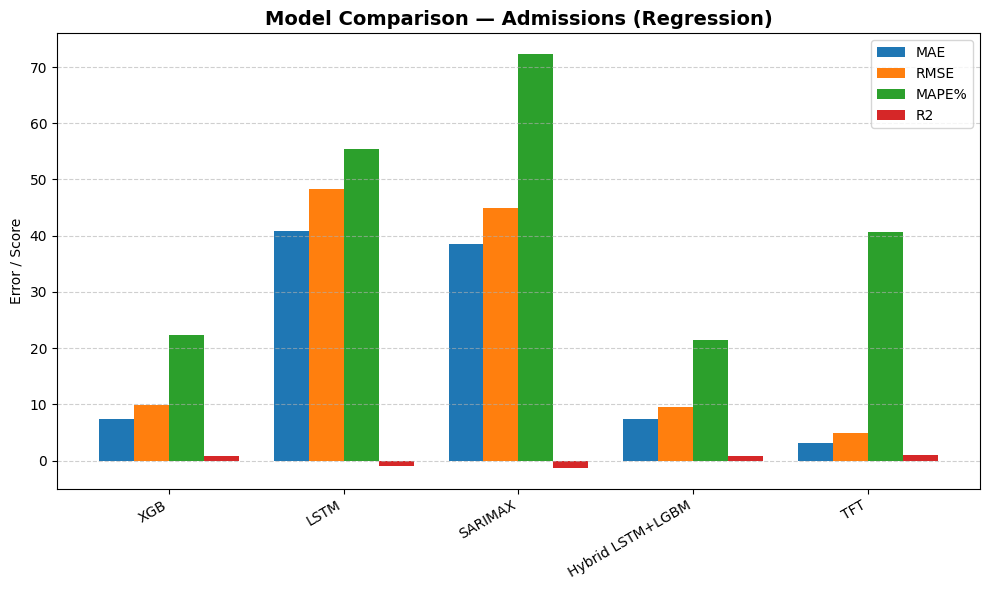

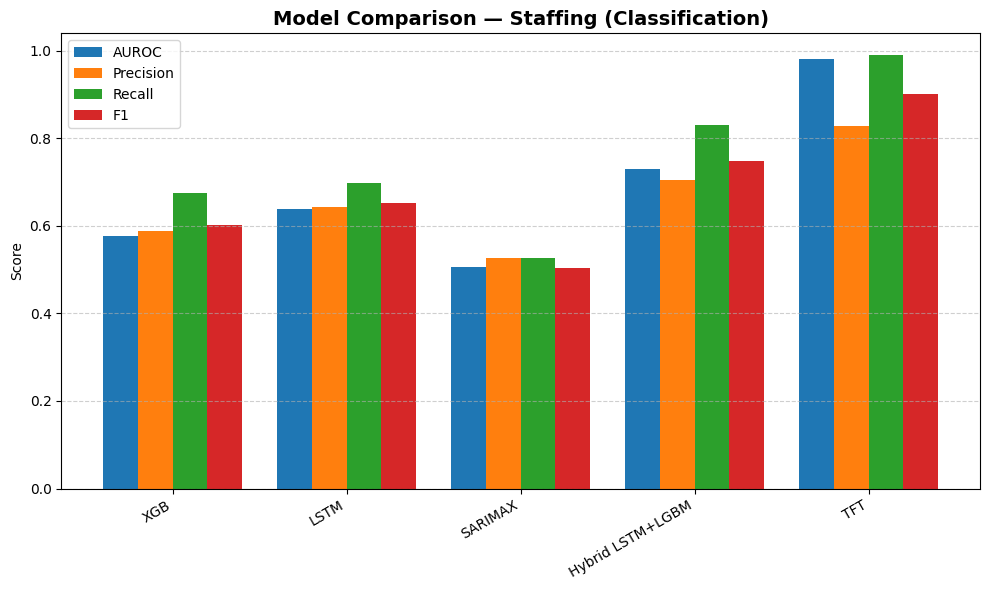

In [35]:
import matplotlib.pyplot as plt
import numpy as np

# -------------------
# DATA
# -------------------
# Admissions (Regression)
admissions_models = ["XGB", "LSTM", "SARIMAX", "Hybrid LSTM+LGBM", "TFT"]
admissions_metrics = {
    "MAE": [7.40, 40.79, 38.59, 7.33, 3.19],
    "RMSE": [9.87, 48.22, 44.98, 9.54, 4.88],
    "MAPE%": [22.39, 55.46, 72.31, 21.37, 40.63],
    "R2": [0.812, -0.875, -1.301, 0.806, 0.928]
}

# Staffing (Classification)
staffing_models = ["XGB", "LSTM", "SARIMAX", "Hybrid LSTM+LGBM", "TFT"]
staffing_metrics = {
    "AUROC": [0.577, 0.639, 0.506, 0.730, 0.982],
    "Precision": [0.588, 0.643, 0.526, 0.704, 0.827],
    "Recall": [0.675, 0.698, 0.526, 0.830, 0.990],
    "F1": [0.603, 0.651, 0.503, 0.748, 0.901]
}

# -------------------
# PLOTTING FUNCTIONS
# -------------------
def plot_metrics(models, metrics, title, ylabel, figsize=(10,6)):
    x = np.arange(len(models))  # model positions
    width = 0.2  # bar width

    fig, ax = plt.subplots(figsize=figsize)

    for i, (metric, values) in enumerate(metrics.items()):
        ax.bar(x + i*width, values, width, label=metric)

    ax.set_title(title, fontsize=14, weight='bold')
    ax.set_xticks(x + width * (len(metrics)-1)/2)
    ax.set_xticklabels(models, rotation=30, ha="right")
    ax.set_ylabel(ylabel)
    ax.legend()
    ax.grid(axis='y', linestyle="--", alpha=0.6)

    plt.tight_layout()
    plt.show()

# -------------------
# PLOTS
# -------------------

# Figure 1: Admissions
plot_metrics(admissions_models, admissions_metrics,
             "Model Comparison — Admissions (Regression)",
             "Error / Score")

# Figure 2: Staffing
plot_metrics(staffing_models, staffing_metrics,
             "Model Comparison — Staffing (Classification)",
             "Score")


[LightGBM] [Info] Number of positive: 940, number of negative: 93
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000431 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1526
[LightGBM] [Info] Number of data points in the train set: 1033, number of used features: 42
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.909971 -> initscore=2.313280
[LightGBM] [Info] Start training from score 2.313280
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 200 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [W

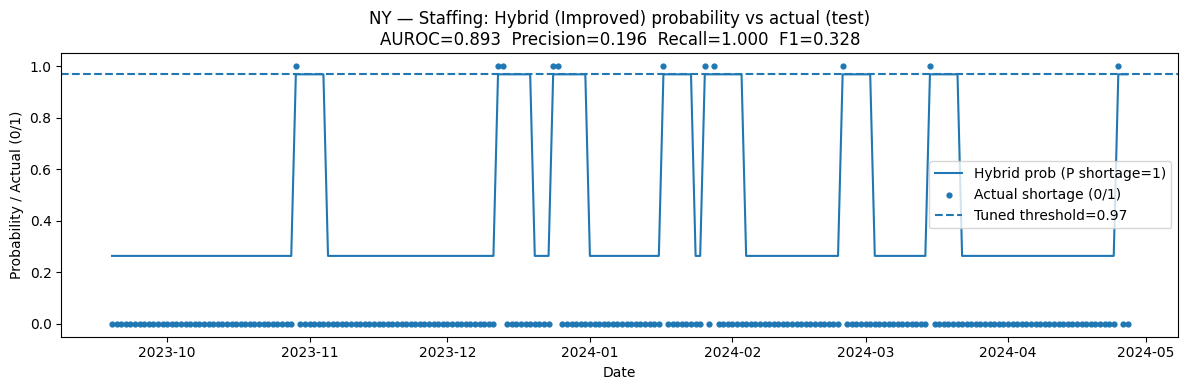

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000710 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7366
[LightGBM] [Info] Number of data points in the train set: 1180, number of used features: 40
[LightGBM] [Info] Start training from score 5.774007
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, 

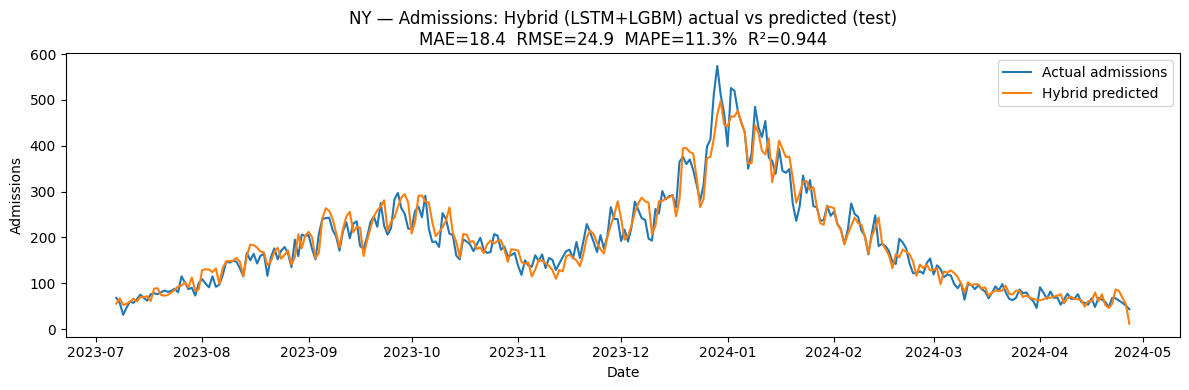

In [36]:
# =========================================
# Compare Hybrid (Improved) predictions vs actuals (graphs)
#  - Staffing: probability line + actual 0/1 + tuned threshold
#  - Admissions: actual vs predicted lines
# =========================================
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import lightgbm as lgb
from lightgbm import LGBMRegressor, LGBMClassifier
import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score,
    roc_auc_score, precision_score, recall_score, f1_score,
    precision_recall_curve
)

# ---------- helpers ----------
def _date_col(df):
    return "collection_date" if "collection_date" in df.columns else ("date" if "date" in df.columns else None)

def reg_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float).reshape(-1)
    y_pred = np.asarray(y_pred, float).reshape(-1)
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    with np.errstate(divide='ignore', invalid='ignore'):
        ape = np.abs((y_true - y_pred) / np.where(y_true==0, np.nan, y_true))
    mape = float(np.nanmean(ape) * 100.0)
    r2   = float(r2_score(y_true, y_pred))
    return mae, rmse, mape, r2

# Staffing windows (IMPROVED: counts + recency + exog)
def make_windows_with_meta_staff(df_state, lookback=30):
    y_bin = (df_state["staffing_yes"] > 0).astype(int).values
    y_cnt = df_state["staffing_yes"].astype(float).values
    Xs, Xm, yy = [], [], []
    for i in range(len(df_state) - lookback):
        t = i + lookback
        Xs.append(y_bin[i:t])  # sequence for LSTM (binary history)

        last_cnt = y_cnt[t-1]
        mean7 = df_state.loc[max(0,t-6):t, "staffing_yes"].mean()
        sum7  = df_state.loc[max(0,t-6):t, "staffing_yes"].sum()
        wow   = last_cnt - (y_cnt[t-7] if t-7>=0 else 0.0)
        meta = [
            y_bin[t-1] if t-1>=0 else 0.0,  # prev_bin
            last_cnt, mean7, sum7, wow,
            df_state.loc[t, "dayofweek"] if "dayofweek" in df_state else 0,
            df_state.loc[t, "month"]     if "month"     in df_state else 0,
            df_state.loc[t, "inpatient_beds"] if "inpatient_beds" in df_state else 0.0,
            df_state.loc[t, "total_adult_patients_hospitalized_confirmed_covid"] if "total_adult_patients_hospitalized_confirmed_covid" in df_state else 0.0,
            df_state.loc[t, "percent_of_inpatients_with_covid"] if "percent_of_inpatients_with_covid" in df_state else 0.0,
            df_state.loc[t, "inpatient_beds_utilization"] if "inpatient_beds_utilization" in df_state else 0.0,
        ]
        Xm.append(meta); yy.append(y_bin[t])
    X_seq = np.asarray(Xs, "float32")[..., None]
    X_meta = np.asarray(Xm, "float32")
    y = np.asarray(yy, "float32")
    return X_seq, X_meta, y

# Admissions windows + meta (same style as before)
def make_windows_with_meta_adm(df_state, lookback=30):
    vals = df_state["admissions"].astype(float).values
    Xs, Xm, yy = [], [], []
    for i in range(len(vals) - lookback):
        w = vals[i:i+lookback]; t = i + lookback
        lag1  = w[-1] - (w[-2] if lookback>=2  else w[-1])
        lag7  = w[-1] - (w[-7] if lookback>=7  else w[-1])
        lag14 = w[-1] - (w[-14] if lookback>=14 else w[-1])
        meta = [
            w[-1], w.mean(), (w.std() if np.isfinite(w.std()) else 0.0), w.min(), w.max(),
            lag1, lag7, lag14,
            df_state.loc[t, "dayofweek"] if "dayofweek" in df_state else 0,
            df_state.loc[t, "month"]     if "month"     in df_state else 0,
            df_state.loc[t, "inpatient_beds"] if "inpatient_beds" in df_state else 0.0,
            df_state.loc[t, "total_adult_patients_hospitalized_confirmed_covid"] if "total_adult_patients_hospitalized_confirmed_covid" in df_state else 0.0,
            df_state.loc[t, "percent_of_inpatients_with_covid"] if "percent_of_inpatients_with_covid" in df_state else 0.0,
            df_state.loc[t, "inpatient_beds_utilization"] if "inpatient_beds_utilization" in df_state else 0.0,
        ]
        Xs.append(w); Xm.append(meta); yy.append(vals[t])
    X_seq = np.asarray(Xs, "float32")[..., None]
    X_meta = np.asarray(Xm, "float32")
    y = np.asarray(yy, "float32")
    return X_seq, X_meta, y

# ---------- 1) Staffing (Improved Hybrid) ----------
def plot_hybrid_staffing_improved_vs_actual(state_daily, STATE="NY", lookback=30, lstm_epochs=15):
    dcol = _date_col(state_daily)
    df = state_daily[state_daily["state"]==STATE].copy().sort_values(dcol).reset_index(drop=True)
    if len(df) < lookback + 80:
        raise ValueError(f"{STATE}: not enough data for lookback={lookback}")

    # windows & aligned dates for targets
    X_seq, X_meta, y = make_windows_with_meta_staff(df, lookback=lookback)
    # dates: each y[t] corresponds to df index t+lookback
    dates = df[dcol].iloc[lookback:].reset_index(drop=True)

    # train/val/test split (time-based)
    M = len(y)
    i_tr = int(0.7 * M)
    i_va = int(0.85 * M)

    Xs_tr, Xm_tr, y_tr = X_seq[:i_tr], X_meta[:i_tr], y[:i_tr]
    Xs_va, Xm_va, y_va = X_seq[i_tr:i_va], X_meta[i_tr:i_va], y[i_tr:i_va]
    Xs_te, Xm_te, y_te = X_seq[i_va:], X_meta[i_va:], y[i_va:]
    dt_te = dates.iloc[i_va:]

    # LSTM encoder -> embedding
    tf.keras.backend.clear_session()
    inp = Input(shape=(lookback,1), name="seq")
    x = LSTM(64, name="lstm")(inp)
    x = Dropout(0.3, name="drop")(x)
    emb = Dense(32, activation="relu", name="emb")(x)
    out = Dense(1, activation="sigmoid", name="out")(emb)
    lstm = Model(inp, out)
    lstm.compile(optimizer="adam", loss="binary_crossentropy")
    lstm.fit(Xs_tr, y_tr, epochs=lstm_epochs, batch_size=64,
             validation_data=(Xs_va, y_va), verbose=0)

    # embeddings
    emb_model = Model(lstm.input, lstm.get_layer("emb").output)
    E_tr = emb_model.predict(Xs_tr, verbose=0)
    E_va = emb_model.predict(Xs_va, verbose=0)
    E_te = emb_model.predict(Xs_te, verbose=0)

    # features for LGBM
    X_tr = np.hstack([E_tr, np.nan_to_num(Xm_tr)])
    X_va = np.hstack([E_va, np.nan_to_num(Xm_va)])
    X_te = np.hstack([E_te, np.nan_to_num(Xm_te)])

    # imbalance handling
    n_pos = max(1, int((y_tr==1).sum()))
    n_neg = max(1, int((y_tr==0).sum()))
    spw   = n_neg / n_pos

    clf = LGBMClassifier(
        objective="binary",
        learning_rate=0.05,
        num_leaves=127,
        min_child_samples=10,
        subsample=0.8,
        colsample_bytree=0.9,
        reg_lambda=1.0,
        n_estimators=4000,
        scale_pos_weight=spw,
        random_state=42
    )
    # version-safe early stopping
    cbs = []
    if hasattr(lgb, "early_stopping"): cbs.append(lgb.early_stopping(stopping_rounds=200))
    if hasattr(lgb, "log_evaluation"): cbs.append(lgb.log_evaluation(period=200))
    clf.fit(X_tr, y_tr.astype(int), eval_set=[(X_va, y_va.astype(int))], callbacks=cbs)

    # probabilities
    p_va = clf.predict_proba(X_va)[:,1]
    p_te = clf.predict_proba(X_te)[:,1]

    # Tune threshold on VALIDATION for max F1 (no test leakage)
    prec, rec, thr = precision_recall_curve(y_va.astype(int), p_va)
    if len(thr):
        f1_vals = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9)
        best_thr = float(thr[int(np.nanargmax(f1_vals))])
    else:
        best_thr = 0.5

    # Test metrics at tuned threshold
    y_pred_te = (p_te >= best_thr).astype(int)
    auroc = float("nan") if len(np.unique(y_te))<2 else float(roc_auc_score(y_te.astype(int), p_te))
    prec_te = float(precision_score(y_te.astype(int), y_pred_te, zero_division=0))
    rec_te  = float(recall_score(y_te.astype(int), y_pred_te, zero_division=0))
    f1_te   = float(f1_score(y_te.astype(int), y_pred_te, zero_division=0))

    # ---- Plot: probability vs actual + threshold
    plt.figure(figsize=(12,4))
    plt.plot(dt_te, p_te, label="Hybrid prob (P shortage=1)")
    plt.scatter(dt_te, y_te, s=12, label="Actual shortage (0/1)")
    plt.axhline(best_thr, linestyle="--", label=f"Tuned threshold={best_thr:.2f}")
    plt.ylim(-0.05, 1.05)
    plt.title(f"{STATE} — Staffing: Hybrid (Improved) probability vs actual (test)\n"
              f"AUROC={auroc:.3f}  Precision={prec_te:.3f}  Recall={rec_te:.3f}  F1={f1_te:.3f}")
    plt.xlabel("Date"); plt.ylabel("Probability / Actual (0/1)"); plt.legend(); plt.tight_layout(); plt.show()

# ---------- 2) Admissions (Hybrid) ----------
def plot_hybrid_admissions_vs_actual(state_daily, STATE="NY", lookback=30, epochs=15, use_log1p=False):
    dcol = _date_col(state_daily)
    df = state_daily[state_daily["state"]==STATE].copy().sort_values(dcol).reset_index(drop=True)
    if len(df) < lookback + 50:
        raise ValueError(f"{STATE}: not enough data for lookback={lookback}")

    X_seq, X_meta, y = make_windows_with_meta_adm(df, lookback=lookback)
    dates = df[dcol].iloc[lookback:].reset_index(drop=True)

    # train/test split (you can add a val split if you like)
    M = len(y)
    i_te = int(0.8 * M)
    Xs_tr, Xm_tr, y_tr = X_seq[:i_te], X_meta[:i_te], y[:i_te]
    Xs_te, Xm_te, y_te = X_seq[i_te:], X_meta[i_te:], y[i_te:]
    dt_te = dates.iloc[i_te:]

    # LSTM encoder -> embedding
    tf.keras.backend.clear_session()
    inp = Input(shape=(lookback,1)); x = LSTM(64)(inp); x = Dropout(0.2)(x)
    emb = Dense(32, activation="relu", name="emb")(x); out = Dense(1)(emb)
    lstm = Model(inp, out); lstm.compile(optimizer="adam", loss="mse")
    y_tr_trf = np.log1p(y_tr) if use_log1p else y_tr
    lstm.fit(Xs_tr, y_tr_trf, epochs=epochs, batch_size=64, validation_split=0.2, verbose=0)

    emb_model = Model(lstm.input, lstm.get_layer("emb").output)
    E_tr = emb_model.predict(Xs_tr, verbose=0)
    E_te = emb_model.predict(Xs_te, verbose=0)

    X_tr = np.hstack([E_tr, np.nan_to_num(Xm_tr)])
    X_te = np.hstack([E_te, np.nan_to_num(Xm_te)])

    gbr = LGBMRegressor(
        objective=("poisson" if not use_log1p else "regression"),
        n_estimators=2000, learning_rate=0.05, num_leaves=63,
        subsample=0.8, colsample_bytree=0.9, reg_lambda=1.0, random_state=42
    )
    gbr.fit(X_tr, y_tr_trf)
    y_hat_trf = gbr.predict(X_te)
    y_hat = np.expm1(y_hat_trf) if use_log1p else y_hat_trf

    mae, rmse, mape, r2 = reg_metrics(y_te, y_hat)

    # ---- Plot: actual vs predicted
    plt.figure(figsize=(12,4))
    plt.plot(dt_te, y_te, label="Actual admissions")
    plt.plot(dt_te, y_hat, label="Hybrid predicted")
    plt.title(f"{STATE} — Admissions: Hybrid (LSTM+LGBM) actual vs predicted (test)\n"
              f"MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%  R²={r2:.3f}")
    plt.xlabel("Date"); plt.ylabel("Admissions"); plt.legend(); plt.tight_layout(); plt.show()

# ======= HOW TO CALL =======
STATE = "NY"     # change to the state you want
LOOKBACK = 30
EPOCHS   = 15

plot_hybrid_staffing_improved_vs_actual(state_daily, STATE=STATE, lookback=LOOKBACK, lstm_epochs=EPOCHS)
plot_hybrid_admissions_vs_actual(state_daily, STATE=STATE, lookback=LOOKBACK, epochs=EPOCHS, use_log1p=False)


INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 1      | train
3  | prescalers       

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HP

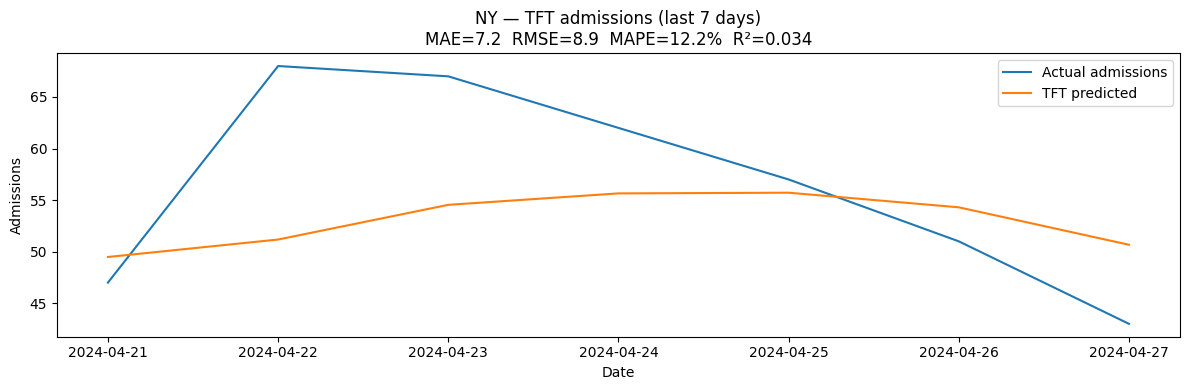

INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 1      | train
3  | prescalers       

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HP

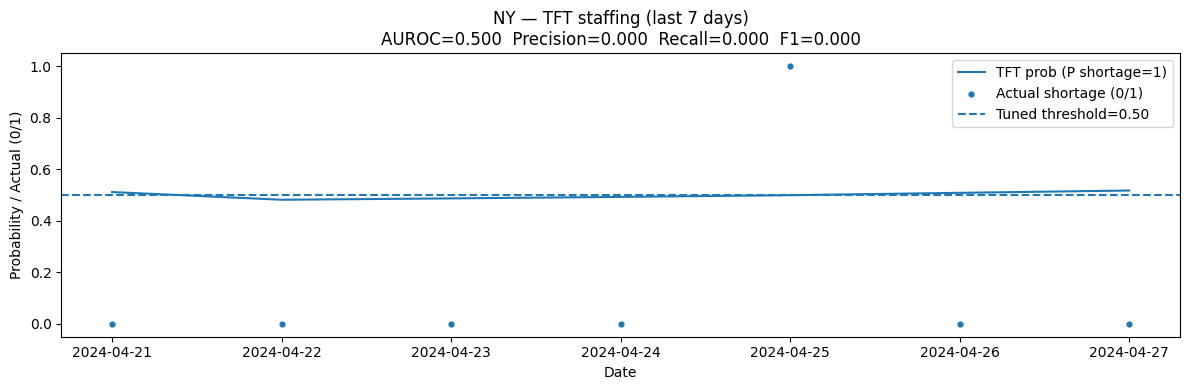

In [37]:
# =========================
# TFT — plots vs actuals (per state)
# =========================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")

# --- metrics helpers ---
from sklearn.metrics import (mean_absolute_error, mean_squared_error, r2_score,
                             roc_auc_score, precision_score, recall_score, f1_score,
                             precision_recall_curve)

def _date_col(df):
    return "collection_date" if "collection_date" in df.columns else ("date" if "date" in df.columns else None)

def _reg_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, float).ravel()
    y_pred = np.asarray(y_pred, float).ravel()
    n = min(len(y_true), len(y_pred))
    y_true, y_pred = y_true[:n], y_pred[:n]
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    with np.errstate(divide='ignore', invalid='ignore'):
        ape = np.abs((y_true - y_pred) / np.where(y_true==0, np.nan, y_true))
    mape = float(np.nanmean(ape) * 100.0)
    r2   = float(r2_score(y_true, y_pred))
    return mae, rmse, mape, r2

# --- robust prediction extractor (works across PF versions) ---
def _tft_predict_and_targets(model, loader):
    import torch, numpy as np
    # predictions
    try:
        preds = model.predict(loader)
    except Exception:
        preds = None
    if preds is None:
        raw = model.predict(loader, mode="raw")
        if isinstance(raw, dict) and "prediction" in raw:
            preds = raw["prediction"]
        elif isinstance(raw, (list, tuple)) and raw:
            preds = raw[0]
        else:
            preds = raw
    if isinstance(preds, dict) and "prediction" in preds:
        preds = preds["prediction"]
    if hasattr(preds, "detach"):
        preds = preds.detach().cpu().numpy()
    preds = np.asarray(preds)
    if preds.ndim == 3:  # sometimes [B, T, quantiles]
        preds = preds[..., preds.shape[-1]//2]
    preds = preds.reshape(-1)

    # targets
    ys = []
    for batch in loader:
        if isinstance(batch, (list, tuple)) and len(batch) >= 2:
            yb = batch[1]
        else:
            xb = batch[0] if isinstance(batch, (list, tuple)) else batch
            if isinstance(xb, dict) and "decoder_target" in xb:
                yb = xb["decoder_target"]
            else:
                continue
        if isinstance(yb, (list, tuple)) and len(yb) >= 1:
            yb = yb[0]
        if hasattr(yb, "detach"):
            yb = yb.detach().cpu().numpy()
        ys.append(np.asarray(yb).reshape(-1))
    y = np.concatenate(ys, axis=0) if ys else np.array([])
    n = min(len(preds), len(y))
    return preds[:n], y[:n]

# --- core TFT trainer + splitter (per state) ---
def _tft_train_val_test_one_state(df_state, target_col, lookback=30, horizon=7, epochs=10, batch_size=64):
    """
    Returns: (dates_val, y_val, pred_val), (dates_test, y_test, pred_test)
    For staffing (binary), preds are logits; apply sigmoid outside.
    """
    import numpy as np, torch
    from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
    from pytorch_forecasting.metrics import RMSE as RMSELoss
    from lightning.pytorch import Trainer

    df = df_state.copy().reset_index(drop=True)
    dcol = _date_col(df)
    if "time_idx" not in df.columns:
        df["time_idx"] = np.arange(len(df))

    # ensure these exist
    for c in ("dayofweek", "month"):
        if c not in df.columns:
            df[c] = getattr(df[dcol].dt, "dayofweek" if c=="dayofweek" else "month")
    if "state" not in df.columns:
        df["state"] = "S"

    # split: [ ... train ... ][ val window ][ test window ]
    min_req = lookback + horizon
    if len(df) < min_req * 3:
        raise ValueError(f"Series too short for lookback={lookback}, horizon={horizon} (need ≥{min_req*3} rows).")
    train_df = df.iloc[:-(2*horizon)].copy()
    val_df   = df.iloc[-(lookback + 2*horizon):-(horizon)].copy()
    test_df  = df.iloc[-(lookback + horizon):].copy()

    # dataset
    tv_known = [c for c in ["dayofweek","month"] if c in df.columns]
    tv_unknown = [target_col]
    train_ds = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target=target_col,
        group_ids=["state"],
        max_encoder_length=lookback,
        max_prediction_length=horizon,
        static_categoricals=["state"],
        time_varying_known_reals=tv_known,
        time_varying_unknown_reals=tv_unknown,
        allow_missing_timesteps=True,
    )
    val_ds  = TimeSeriesDataSet.from_dataset(train_ds, val_df,  predict=True, stop_randomization=True)
    test_ds = TimeSeriesDataSet.from_dataset(train_ds, test_df, predict=True, stop_randomization=True)

    train_loader = train_ds.to_dataloader(train=True,  batch_size=batch_size, num_workers=0)
    val_loader   = val_ds.to_dataloader(  train=False, batch_size=batch_size, num_workers=0)
    test_loader  = test_ds.to_dataloader( train=False, batch_size=batch_size, num_workers=0)

    # model
    loss_fn = RMSELoss()  # keep regression head; sigmoid later for binary
    tft = TemporalFusionTransformer.from_dataset(
        train_ds,
        learning_rate=1e-3,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.1,
        loss=loss_fn,
        optimizer="Adam",
        output_size=1,
    )
    accelerator = "gpu" if torch.cuda.is_available() else "cpu"
    trainer = Trainer(max_epochs=epochs, accelerator=accelerator, devices=1, gradient_clip_val=0.1, log_every_n_steps=50)
    trainer.fit(tft, train_loader, val_loader)

    # predictions
    p_val, y_val   = _tft_predict_and_targets(tft, val_loader)
    p_test, y_test = _tft_predict_and_targets(tft, test_loader)

    # dates for plotting (decoder windows align to last horizon in each slice)
    dates_val  = val_df[_date_col(val_df)].iloc[-horizon:].reset_index(drop=True)
    dates_test = test_df[_date_col(test_df)].iloc[-horizon:].reset_index(drop=True)
    return (dates_val, y_val, p_val), (dates_test, y_test, p_test)

# =========================
# PUBLIC: plotters
# =========================

def plot_tft_admissions_vs_actual(state_daily, STATE="NY", lookback=30, horizon=7, epochs=10, batch_size=64):
    dcol = _date_col(state_daily)
    df_state = (state_daily[state_daily["state"]==STATE]
                .sort_values(dcol).reset_index(drop=True)).copy()
    # train + predict
    (dval, yv, pv), (dte, yt, pt) = _tft_train_val_test_one_state(
        df_state, target_col="admissions",
        lookback=lookback, horizon=horizon, epochs=epochs, batch_size=batch_size
    )
    # metrics on test
    mae, rmse, mape, r2 = _reg_metrics(yt, pt)

    # plot
    plt.figure(figsize=(12,4))
    plt.plot(dte, yt, label="Actual admissions")
    plt.plot(dte, pt, label="TFT predicted")
    plt.title(f"{STATE} — TFT admissions (last {horizon} days)\n"
              f"MAE={mae:.1f}  RMSE={rmse:.1f}  MAPE={mape:.1f}%  R²={r2:.3f}")
    plt.xlabel("Date"); plt.ylabel("Admissions"); plt.legend(); plt.tight_layout(); plt.show()

def plot_tft_staffing_vs_actual(state_daily, STATE="NY", lookback=30, horizon=7, epochs=10, batch_size=64):
    dcol = _date_col(state_daily)
    df_state = (state_daily[state_daily["state"]==STATE]
                .sort_values(dcol).reset_index(drop=True)).copy()
    # binary target
    if "staffing_bin" not in df_state.columns:
        df_state["staffing_bin"] = (df_state["staffing_yes"] > 0).astype(int)

    # train + predict (preds are logits; we apply sigmoid)
    (dval, yv, pv), (dte, yt, pt) = _tft_train_val_test_one_state(
        df_state, target_col="staffing_bin",
        lookback=lookback, horizon=horizon, epochs=epochs, batch_size=batch_size
    )
    # logits -> probabilities
    sig = lambda z: 1.0/(1.0+np.exp(-z))
    p_val = sig(pv); p_test = sig(pt)

    # tune threshold on validation for max F1 (no test leakage)
    thr = 0.5
    if len(np.unique(yv.astype(int))) > 1:
        prec, rec, thr_grid = precision_recall_curve(yv.astype(int), p_val)
        if len(thr_grid):
            f1 = 2*prec[:-1]*rec[:-1]/(prec[:-1]+rec[:-1]+1e-9)
            thr = float(thr_grid[int(np.nanargmax(f1))])

    # test metrics @ tuned threshold
    auroc = float("nan") if len(np.unique(yt.astype(int)))<2 else float(roc_auc_score(yt.astype(int), p_test))
    y_pred = (p_test >= thr).astype(int)
    prec = float(precision_score(yt.astype(int), y_pred, zero_division=0))
    rec  = float(recall_score(yt.astype(int), y_pred, zero_division=0))
    f1   = float(f1_score(yt.astype(int), y_pred, zero_division=0))

    # plot probability vs actual with threshold
    plt.figure(figsize=(12,4))
    plt.plot(dte, p_test, label="TFT prob (P shortage=1)")
    plt.scatter(dte, yt, s=12, label="Actual shortage (0/1)")
    plt.axhline(thr, linestyle="--", label=f"Tuned threshold={thr:.2f}")
    plt.ylim(-0.05, 1.05)
    plt.title(f"{STATE} — TFT staffing (last {horizon} days)\n"
              f"AUROC={auroc:.3f}  Precision={prec:.3f}  Recall={rec:.3f}  F1={f1:.3f}")
    plt.xlabel("Date"); plt.ylabel("Probability / Actual (0/1)"); plt.legend(); plt.tight_layout(); plt.show()

# =========================
# HOW TO CALL
# =========================
STATE    = "NY"   # change to the state you want
LOOKBACK = 30
HORIZON  = 7
EPOCHS   = 10

plot_tft_admissions_vs_actual(state_daily, STATE=STATE, lookback=LOOKBACK, horizon=HORIZON, epochs=EPOCHS)
plot_tft_staffing_vs_actual(state_daily, STATE=STATE, lookback=LOOKBACK, horizon=HORIZON, epochs=EPOCHS)


In [43]:
# =========================
# Separate ROC plots: Hybrid (Improved) and TFT
# =========================
import numpy as np, pandas as pd, matplotlib.pyplot as plt, warnings
warnings.filterwarnings("ignore")

from sklearn.metrics import roc_curve, roc_auc_score
import lightgbm as lgb
from lightgbm import LGBMClassifier

import tensorflow as tf
from tensorflow.keras import Model, Input
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ---------- helpers ----------
def _date_col(df):
    return "collection_date" if "collection_date" in df.columns else ("date" if "date" in df.columns else None)

def _make_windows_with_meta_staff(df_state, lookback=30):
    """
    Sequence: past staffing_bin, Meta: counts + rolling + exogenous (improved hybrid features).
    """
    y_bin = (df_state["staffing_yes"] > 0).astype(int).values
    y_cnt = df_state["staffing_yes"].astype(float).values
    Xs, Xm, yy = [], [], []
    for i in range(len(df_state) - lookback):
        t = i + lookback
        Xs.append(y_bin[i:t])
        last_cnt = y_cnt[t-1]
        mean7 = df_state.loc[max(0,t-6):t, "staffing_yes"].mean()
        sum7  = df_state.loc[max(0,t-6):t, "staffing_yes"].sum()
        wow   = last_cnt - (y_cnt[t-7] if t-7>=0 else 0.0)
        meta = [
            y_bin[t-1] if t-1>=0 else 0.0,  # prev bin
            last_cnt, mean7, sum7, wow,
            df_state.loc[t, "dayofweek"] if "dayofweek" in df_state else 0,
            df_state.loc[t, "month"]     if "month"     in df_state else 0,
            df_state.loc[t, "inpatient_beds"] if "inpatient_beds" in df_state else 0.0,
            df_state.loc[t, "total_adult_patients_hospitalized_confirmed_covid"] if "total_adult_patients_hospitalized_confirmed_covid" in df_state else 0.0,
            df_state.loc[t, "percent_of_inpatients_with_covid"] if "percent_of_inpatients_with_covid" in df_state else 0.0,
            df_state.loc[t, "inpatient_beds_utilization"] if "inpatient_beds_utilization" in df_state else 0.0,
        ]
        Xm.append(meta); yy.append(y_bin[t])
    X_seq = np.asarray(Xs, "float32")[..., None]
    X_meta = np.asarray(Xm, "float32")
    y = np.asarray(yy, "float32")
    return X_seq, X_meta, y

# ---------- Hybrid (Improved) -> y_test, p_test ----------
def hybrid_staffing_probs(state_daily, STATE="NY", lookback=30, lstm_epochs=15,
                          val_frac=0.15, test_frac=0.25):
    import numpy as np, lightgbm as lgb
    from lightgbm import LGBMClassifier
    import tensorflow as tf
    from tensorflow.keras import Model, Input
    from tensorflow.keras.layers import LSTM, Dense, Dropout

    def _date_col(df):
        return "collection_date" if "collection_date" in df.columns else ("date" if "date" in df.columns else None)

    dcol = _date_col(state_daily)
    df = (state_daily[state_daily["state"]==STATE]
          .sort_values(dcol).reset_index(drop=True)).copy()

    # --- windows (same improved features as before) ---
    y_bin = (df["staffing_yes"] > 0).astype(int).values
    y_cnt = df["staffing_yes"].astype(float).values
    Xs, Xm, yy = [], [], []
    for i in range(len(df) - lookback):
        t = i + lookback
        Xs.append(y_bin[i:t])
        last_cnt = y_cnt[t-1]
        mean7 = df.loc[max(0,t-6):t, "staffing_yes"].mean()
        sum7  = df.loc[max(0,t-6):t, "staffing_yes"].sum()
        wow   = last_cnt - (y_cnt[t-7] if t-7>=0 else 0.0)
        meta = [
            y_bin[t-1] if t-1>=0 else 0.0,
            last_cnt, mean7, sum7, wow,
            df.loc[t, "dayofweek"] if "dayofweek" in df else 0,
            df.loc[t, "month"]     if "month"     in df else 0,
            df.loc[t, "inpatient_beds"] if "inpatient_beds" in df else 0.0,
            df.loc[t, "total_adult_patients_hospitalized_confirmed_covid"] if "total_adult_patients_hospitalized_confirmed_covid" in df else 0.0,
            df.loc[t, "percent_of_inpatients_with_covid"] if "percent_of_inpatients_with_covid" in df else 0.0,
            df.loc[t, "inpatient_beds_utilization"] if "inpatient_beds_utilization" in df else 0.0,
        ]
        Xm.append(meta); yy.append(y_bin[t])

    Xs = np.asarray(Xs, "float32")[..., None]
    Xm = np.asarray(Xm, "float32")
    y  = np.asarray(yy, "float32")
    M  = len(y)
    assert 0 < val_frac < 1 and 0 < test_frac < 1 and val_frac + test_frac < 1, "bad fractions"

    i_tr = int((1.0 - val_frac - test_frac) * M)
    i_va = int((1.0 - test_frac) * M)

    Xs_tr, Xm_tr, y_tr = Xs[:i_tr], Xm[:i_tr], y[:i_tr]
    Xs_va, Xm_va, y_va = Xs[i_tr:i_va], Xm[i_tr:i_va], y[i_tr:i_va]
    Xs_te, Xm_te, y_te = Xs[i_va:],    Xm[i_va:],    y[i_va:]

    # LSTM encoder -> embedding
    tf.keras.backend.clear_session()
    inp = Input(shape=(lookback,1)); x = LSTM(64)(inp); x = Dropout(0.3)(x)
    emb = Dense(32, activation="relu", name="emb")(x); out = Dense(1, activation="sigmoid")(emb)
    lstm = Model(inp, out); lstm.compile(optimizer="adam", loss="binary_crossentropy")
    lstm.fit(Xs_tr, y_tr, epochs=lstm_epochs, batch_size=64,
             validation_data=(Xs_va, y_va), verbose=0)

    emb_model = Model(lstm.input, lstm.get_layer("emb").output)
    E_tr = emb_model.predict(Xs_tr, verbose=0)
    E_va = emb_model.predict(Xs_va, verbose=0)
    E_te = emb_model.predict(Xs_te, verbose=0)

    X_tr = np.hstack([E_tr, np.nan_to_num(Xm_tr)])
    X_va = np.hstack([E_va, np.nan_to_num(Xm_va)])
    X_te = np.hstack([E_te, np.nan_to_num(Xm_te)])

    # imbalance handling
    n_pos = max(1, int((y_tr==1).sum())); n_neg = max(1, int((y_tr==0).sum()))
    spw = n_neg/n_pos

    clf = LGBMClassifier(objective="binary", n_estimators=4000, learning_rate=0.05,
                         num_leaves=127, min_child_samples=10, subsample=0.8,
                         colsample_bytree=0.9, reg_lambda=1.0, scale_pos_weight=spw, random_state=42)
    cbs = []
    if hasattr(lgb, "early_stopping"): cbs.append(lgb.early_stopping(stopping_rounds=200))
    if hasattr(lgb, "log_evaluation"): cbs.append(lgb.log_evaluation(period=200))
    clf.fit(X_tr, y_tr.astype(int), eval_set=[(X_va, y_va.astype(int))], callbacks=cbs)

    p_te = clf.predict_proba(X_te)[:,1]
    return y_te.astype(int), np.clip(p_te, 1e-9, 1-1e-9)


# ---------- TFT -> y_test, p_test ----------
def tft_staffing_probs(state_daily, STATE="NY", lookback=30, horizon=7, epochs=10, batch_size=64):
    import numpy as np
    import torch
    from pytorch_forecasting import TimeSeriesDataSet, TemporalFusionTransformer
    from pytorch_forecasting.metrics import RMSE as RMSELoss
    from lightning.pytorch import Trainer

    def _date_col(df):
        return "collection_date" if "collection_date" in df.columns else ("date" if "date" in df.columns else None)

    dcol = _date_col(state_daily)
    df = (state_daily[state_daily["state"]==STATE]
          .sort_values(dcol).reset_index(drop=True)).copy()
    if "staffing_bin" not in df.columns:
        df["staffing_bin"] = (df["staffing_yes"] > 0).astype(int)
    if "time_idx" not in df.columns:
        df["time_idx"] = np.arange(len(df))

    min_req = (lookback + horizon) * 3
    if len(df) < min_req:
        raise ValueError(f"{STATE}: need ≥{min_req} rows for lookback={lookback}, horizon={horizon}")

    # train / val / test windows
    train_df = df.iloc[:-(2*horizon)].copy()
    val_df   = df.iloc[-(lookback + 2*horizon):-(horizon)].copy()
    test_df  = df.iloc[-(lookback + horizon):].copy()

    tv_known = [c for c in ["dayofweek","month"] if c in df.columns]
    train_ds = TimeSeriesDataSet(
        train_df,
        time_idx="time_idx",
        target="staffing_bin",
        group_ids=["state"],
        max_encoder_length=lookback,
        max_prediction_length=horizon,
        static_categoricals=["state"],
        time_varying_known_reals=tv_known,
        time_varying_unknown_reals=["staffing_bin"],
        allow_missing_timesteps=True,
    )
    val_ds  = TimeSeriesDataSet.from_dataset(train_ds, val_df,  predict=True, stop_randomization=True)
    test_ds = TimeSeriesDataSet.from_dataset(train_ds, test_df, predict=True, stop_randomization=True)

    train_loader = train_ds.to_dataloader(train=True,  batch_size=batch_size, num_workers=0)
    val_loader   = val_ds.to_dataloader(  train=False, batch_size=batch_size, num_workers=0)
    test_loader  = test_ds.to_dataloader( train=False, batch_size=batch_size, num_workers=0)

    tft = TemporalFusionTransformer.from_dataset(
        train_ds,
        learning_rate=1e-3,
        hidden_size=64,
        attention_head_size=4,
        dropout=0.1,
        loss=RMSELoss(),   # keep regression head; we'll sigmoid outputs
        optimizer="Adam",
        output_size=1,
    )
    acc = "gpu" if torch.cuda.is_available() else "cpu"
    trainer = Trainer(max_epochs=epochs, accelerator=acc, devices=1, gradient_clip_val=0.1, log_every_n_steps=50)
    trainer.fit(tft, train_loader, val_loader)

    # ---------- robust preds + y extractor (handles (target, weight)) ----------
    def _pred_and_y(model, loader):
        # predictions
        try:
            preds = model.predict(loader)
        except Exception:
            preds = None
        if preds is None:
            raw = model.predict(loader, mode="raw")
            if isinstance(raw, dict) and "prediction" in raw:
                preds = raw["prediction"]
            elif isinstance(raw, (list, tuple)) and len(raw) > 0:
                preds = raw[0]
            else:
                preds = raw
        if hasattr(preds, "detach"):
            preds = preds.detach().cpu().numpy()
        preds = np.asarray(preds)
        if preds.ndim == 3:  # sometimes [B, T, Q]
            preds = preds[..., preds.shape[-1]//2]
        preds = preds.reshape(-1)

        # targets
        ys = []
        for batch in loader:
            # PF DataLoader usually yields (x, (y, weight)) or (x, y)
            if isinstance(batch, (list, tuple)) and len(batch) >= 2:
                candidate = batch[1]
                # if it's (y, weight) take y
                if isinstance(candidate, (list, tuple)) and len(candidate) >= 1:
                    yb = candidate[0]
                else:
                    yb = candidate
            else:
                # fallback: try reading from x dict
                xb = batch[0] if isinstance(batch, (list, tuple)) else batch
                yb = xb["decoder_target"] if isinstance(xb, dict) and "decoder_target" in xb else None
                if yb is None:
                    continue

            if hasattr(yb, "detach"):
                yb = yb.detach().cpu().numpy()
            yb = np.asarray(yb)
            # yb shapes seen: [B, T] or [B, T, 1]
            if yb.ndim == 3 and yb.shape[-1] == 1:
                yb = yb[..., 0]
            ys.append(yb.reshape(-1))

        y = np.concatenate(ys, axis=0) if ys else np.array([])
        n = min(len(preds), len(y))
        return preds[:n], y[:n]

    p_test_logits, y_test = _pred_and_y(tft, test_loader)
    p_test = 1.0 / (1.0 + np.exp(-p_test_logits))  # logits -> probabilities
    return y_test.astype(int), np.clip(p_test, 1e-9, 1-1e-9)


# ---------- Single-plot helpers ----------
def plot_roc_single(y_true, p_scores, title_prefix):
    if len(np.unique(y_true)) < 2:
        print(f"{title_prefix}: Only one class present in y_true — ROC/AUC undefined.")
        return
    fpr, tpr, _ = roc_curve(y_true, p_scores)
    auc_val = roc_auc_score(y_true, p_scores)
    plt.figure(figsize=(6,5))
    plt.plot(fpr, tpr, label=f"AUC={auc_val:.3f}")
    plt.plot([0,1],[0,1], "--", label="Chance")
    plt.xlabel("False Positive Rate"); plt.ylabel("True Positive Rate")
    plt.title(f"{title_prefix} — ROC")
    plt.legend(); plt.tight_layout(); plt.show()




[LightGBM] [Info] Number of positive: 792, number of negative: 93
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000411 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1522
[LightGBM] [Info] Number of data points in the train set: 885, number of used features: 43
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.894915 -> initscore=2.141962
[LightGBM] [Info] Start training from score 2.141962
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
Training until validation scores don't improve for 200 rounds
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Wa

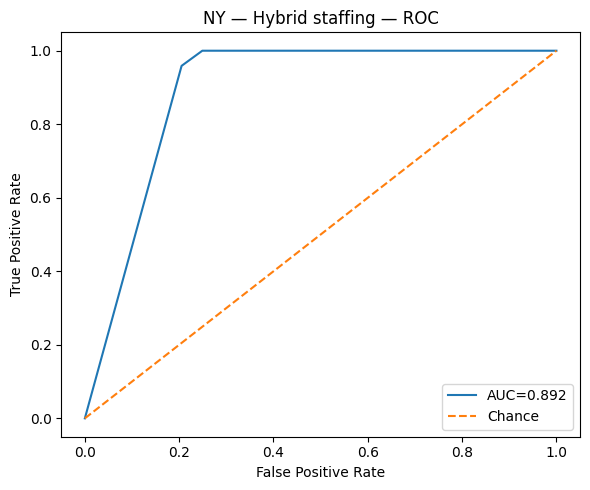

In [44]:
# =========================
# HOW TO CALL (separate ROC figures)
# =========================
STATE    = "NY"   # pick your state
LOOKBACK = 30
HORIZON  = 7

# Hybrid (Improved)
# 30% test, 10% val
y_h, p_h = hybrid_staffing_probs(state_daily, STATE="NY", lookback=30,
                                 lstm_epochs=15, val_frac=0.10, test_frac=0.30)
plot_roc_single(y_h, p_h, title_prefix=f"{STATE} — Hybrid staffing")



INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO: 
   | Name                               | Type                            | Params | Mode 
------------------------------------------------------------------------------------------------
0  | loss                               | RMSE                            | 0      | train
1  | logging_metrics                    | ModuleList                      | 0      | train
2  | input_embeddings                   | MultiEmbedding                  | 1      | train
3  | prescalers       

Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO: `Trainer.fit` stopped: `max_epochs=10` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: HPU available: False, using: 0 HPUs
INFO:lightning.pytorch.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


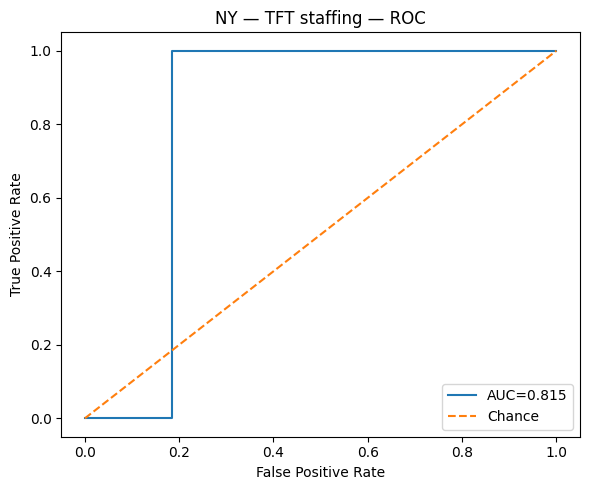

In [45]:
# TFT
y_t, p_t = tft_staffing_probs(state_daily, STATE=STATE, lookback=LOOKBACK, horizon=28, epochs=10)
plot_roc_single(y_t, p_t, title_prefix=f"{STATE} — TFT staffing")

In [ ]:
out_staff = run_tft_predict(
    state_daily, target_col="staffing_bin", task="clf",
    max_encoder_length=30, max_prediction_length=7, epochs=10, batch_size=64
)

# staff_metrics = classification_metrics(out_staff["y_true"], out_staff["probs"], threshold=0.5)/


plot_roc_single(out_staff["y_true"], out_staff["probs"], title_prefix=f"{STATE} — TFT staffing")